# DR-VERGE — Complete Pipeline Notebook

**View-Evidence Relational Grading Engine** — dual-view diabetic retinopathy grading via
Complementarity-Shift Distillation (CSD). GEMASTIK XIX, Bidang VII KTI.

This single notebook runs the **entire experiment**, top to bottom, on a Colab GPU runtime:

1. Setup (Drive mount, dependencies, GPU check)
2. Dataset verification (Gate 1) — DRTiD primary, patient-wise official split
3. All source code inline: datasets, models (CORALHead / Teacher / Student), losses (CORAL, KD, CSD)
4. Smoke test
5. Backbone pretraining on APTOS (ResNet-50 for teacher, lightweight for student)
6. Teacher training (Gate 2)
7. Student baselines: macula-only, disc-only, no-distill, standard KD (3 seeds each for the core 3)
8. CSD signal check (Gate 3), grid search, final DR-VERGE training (3 seeds)
9. PTQ INT8 quantization (Gate 5)
10. Full evaluation, seed aggregation, clustered bootstrap CIs
11. Chart generation (all figures saved as PNG)
12. Final results dashboard

**Every checkpoint, metric CSV, and figure is saved to Google Drive** as it's produced, so a
disconnected Colab runtime never loses completed work — re-running a cell whose output already
exists on Drive skips straight to the next step where practical.

Source of truth for the method: `docs/overview.md`, `docs/[USED THIS] Technical Documentation.pdf`
(v2), `docs/judge.md` (external audit — fixes for its flags are implemented directly in this
notebook's model/loss code, not just described). Day-by-day plan: `docs/roadmap.md`.

**Before running:** set `DRIVE_BASE` in the Config cell to a folder in your Google Drive, and make
sure `dataset/DRTiD/DRTiD/...` and `dataset/APTOS/...` exist there (or use the upload cell to get
them there) — see the Setup section below for both paths.

## 1. Setup

In [1]:
# 1.1 GPU check -- stop here if this doesn't show a GPU (Runtime > Change runtime type > GPU)
!nvidia-smi

Sat Aug  8 08:13:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# 1.2 Mount Google Drive -- this is where the dataset lives and where all outputs get saved,
# so results and checkpoints survive a disconnected runtime.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1.3 Get the dataset onto Drive (one-time, skip if already there)

Two options:

- **Already synced**: if `dataset/DRTiD` and `dataset/APTOS` already exist under `DRIVE_BASE`
  (set below), skip straight to 1.4.
- **First time**: zip your local `dataset/` folder (DRTiD + APTOS subfolders) and upload it via
  the cell below, or upload directly into Drive through the Drive web UI (faster for large
  folders than a browser upload) and skip this cell.

In [ ]:
# 1.3 (optional) Upload a dataset.zip via the browser if it is not already on Drive.
# Skip this cell if dataset/DRTiD and dataset/APTOS already exist under DRIVE_BASE.
RUN_UPLOAD_CELL = False  # flip to True if you need to upload

if RUN_UPLOAD_CELL:
    from google.colab import files
    import zipfile, os
    uploaded = files.upload()  # select dataset.zip (contains DRTiD/ and APTOS/ at top level)
    zip_name = list(uploaded.keys())[0]
    with zipfile.ZipFile(zip_name, "r") as zf:
        zf.extractall("/content/drive/MyDrive/DR-VERGE/dataset")
    print("Extracted to /content/drive/MyDrive/DR-VERGE/dataset")

In [3]:
# 1.4 Install dependencies. Colab already ships a CUDA-enabled torch -- we deliberately do NOT
# reinstall torch/torchvision here to avoid clobbering the platform's GPU build with a
# mismatched one (this is exactly the trap that cost time locally where the dev machine had a
# CPU-only torch and an old driver -- see docs/roadmap.md Day 1 notes).
!pip install -q albumentations scikit-learn==1.9.0 pandas tqdm pyyaml

import torch
print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
assert torch.cuda.is_available(), "No GPU detected -- check Runtime > Change runtime type > GPU."

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 36.6 MB/s eta 0:00:00
torch: 2.11.0+cu128 | CUDA available: True


## 2. Global Config

In [4]:
import os

# ---- EDIT THIS to your Drive folder ----
DRIVE_BASE = "/content/drive/MyDrive/DR-VERGE"

DATASET_ROOT   = f"{DRIVE_BASE}/dataset"
# DRTiD ships nested as DRTiD/DRTiD/... on the original distribution, but folders sometimes get
# flattened to DRTiD/... during manual reorganization -- auto-detect whichever is actually
# present rather than hardcoding one and silently breaking if your Drive layout differs from
# whatever a previous run happened to use.
def _resolve_drtid_root(dataset_root):
    nested = f"{dataset_root}/DRTiD/DRTiD"
    flat = f"{dataset_root}/DRTiD"
    if os.path.exists(f"{nested}/Ground Truths/DR_grade/a. DR_grade_Training.csv"):
        return nested
    if os.path.exists(f"{flat}/Ground Truths/DR_grade/a. DR_grade_Training.csv"):
        return flat
    return nested  # neither exists yet -- fall through to the Gate 1 check below for a clear error

DRTID_ROOT     = _resolve_drtid_root(DATASET_ROOT)
APTOS_ROOT     = f"{DATASET_ROOT}/APTOS"
SPLITS_DIR     = f"{DRIVE_BASE}/splits"
CKPT_DIR       = f"{DRIVE_BASE}/checkpoints"
RESULTS_DIR    = f"{DRIVE_BASE}/results"
FIGURES_DIR    = f"{RESULTS_DIR}/figures"
METRICS_DIR    = f"{RESULTS_DIR}/metrics"
LOGS_DIR       = f"{RESULTS_DIR}/logs"

for d in [SPLITS_DIR, CKPT_DIR, f"{CKPT_DIR}/pretrained_backbones", f"{CKPT_DIR}/teacher",
          f"{CKPT_DIR}/student", RESULTS_DIR, FIGURES_DIR, METRICS_DIR, LOGS_DIR]:
    os.makedirs(d, exist_ok=True)

# Sanity check dataset is where we expect it
_expected = [
    f"{DRTID_ROOT}/Ground Truths/DR_grade/a. DR_grade_Training.csv",
    f"{DRTID_ROOT}/Ground Truths/DR_grade/b. DR_grade_Testing.csv",
    f"{DRTID_ROOT}/Original Images",
    f"{APTOS_ROOT}/train_1.csv",
    f"{APTOS_ROOT}/valid.csv",
    f"{APTOS_ROOT}/train_images/train_images",
    f"{APTOS_ROOT}/val_images/val_images",
]
_missing = [p for p in _expected if not os.path.exists(p)]
if _missing:
    raise FileNotFoundError(
        "Dataset not found at the expected Drive path -- see Section 1.3:\n" + "\n".join(_missing)
    )
print(f"Dataset check OK. DRTID_ROOT resolved to: {DRTID_ROOT}")

SEEDS = [42, 123, 2026]
PRIMARY_SEED = 42
IMG_SIZE = 224
NUM_CLASSES = 5
NUM_THRESHOLDS = NUM_CLASSES - 1

Dataset check OK. DRTID_ROOT resolved to: /content/drive/MyDrive/DR-VERGE/dataset/DRTiD


## 3. Reproducibility utils

In [5]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def make_generator(seed: int) -> torch.Generator:
    g = torch.Generator()
    g.manual_seed(seed)
    return g

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

def compute_pos_weights(train_csv: str, num_thresholds: int = NUM_THRESHOLDS, grade_col: str = "grade") -> torch.Tensor:
    # pos_weight_k = N_negative_k / N_positive_k, for F.binary_cross_entropy_with_logits.
    # Computed ONCE from the training split, reused for every condition/seed so that
    # differences in performance come from the distillation method, not from some
    # conditions accidentally getting better imbalance handling than others.
    df = pd.read_csv(train_csv)
    grades = df[grade_col].values
    weights = []
    for k in range(num_thresholds):
        pos = int((grades > k).sum())
        neg = int((grades <= k).sum())
        if pos == 0 or neg == 0:
            raise ValueError(f"pos_weight threshold k={k} has pos={pos}, neg={neg} -- degenerate split.")
        weights.append(neg / pos)
    return torch.tensor(weights, dtype=torch.float32)

def robust_torch_load(path, map_location=None, retries=6, initial_delay=1.0):
    # Google Drive's FUSE mount has a short, well-documented sync lag: a file written in one line
    # can raise FileNotFoundError on a plain torch.load() of that exact same path on the very next
    # line, in the same running process. Observed directly on a real run: a teacher checkpoint
    # saved at the end of the freeze phase failed to load moments later when starting the finetune
    # phase. Retries with exponential backoff rather than letting a filesystem race kill a training
    # run that otherwise worked correctly. Use this in place of plain torch.load(...) for every
    # checkpoint this notebook itself may have just written, not just ones from a prior session.
    import time as _time
    delay = initial_delay
    last_err = None
    for attempt in range(retries):
        try:
            return torch.load(path, map_location=map_location)
        except (FileNotFoundError, OSError) as e:
            last_err = e
            if attempt < retries - 1:
                print(f"robust_torch_load: '{path}' not readable yet (attempt {attempt+1}/{retries}), retrying in {delay:.1f}s...")
                _time.sleep(delay)
                delay *= 1.5
    raise last_err

def robust_torch_save(obj, path, retries=6, initial_delay=1.0):
    # Mirrors robust_torch_load, for the write side. Google Drive's FUSE mount can lag behind its
    # own directory creation too, not just file writes: confirmed directly on a real run --
    # os.makedirs(parent, exist_ok=True) returned successfully, but torch.save()'s lower-level
    # file writer then raised "RuntimeError: Parent directory ... does not exist" on the very
    # first student checkpoint save moments later. Retries the makedirs+save pair together rather
    # than letting a transient Drive sync lag kill a training run. Use this in place of plain
    # torch.save(...) for every checkpoint this notebook writes.
    import time as _time
    delay = initial_delay
    last_err = None
    parent = os.path.dirname(path)
    for attempt in range(retries):
        try:
            if parent:
                os.makedirs(parent, exist_ok=True)
            torch.save(obj, path)
            return
        except (RuntimeError, OSError, FileNotFoundError) as e:
            last_err = e
            if attempt < retries - 1:
                print(f"robust_torch_save: saving to '{path}' failed (attempt {attempt+1}/{retries}): {e} -- retrying in {delay:.1f}s...")
                _time.sleep(delay)
                delay *= 1.5
    raise last_err

def checkpoint_is_compatible(ckpt_path, model, unwrap_key="model_state"):
    # Returns True only if ckpt_path exists AND its saved state's keys+shapes exactly match
    # `model`'s CURRENT architecture. Guards the "skip training if checkpoint already exists"
    # pattern used throughout this notebook: without this, changing a model's architecture (e.g.
    # the InteractionFusion redesign in Section 6) and then re-running against an old checkpoint
    # on Drive would either silently reuse stale/incompatible weights or crash confusingly deep
    # inside a later cell. If incompatible, prints why and returns False so the caller retrains.
    #
    # Deliberately does NOT call model.load_state_dict(..., strict=True) on the live model --
    # PyTorch's strict load can copy some matching-name parameters into the module in place
    # before it finally raises on a key/shape mismatch elsewhere, which would leave `model`
    # partially mutated (some fresh-init, some stale-loaded) if the caller then falls through to
    # training on it. Comparing key sets and shapes directly against a state_dict() snapshot
    # never touches the real model, so a "not compatible" verdict is always side-effect-free.
    if not os.path.exists(ckpt_path):
        return False
    try:
        raw = robust_torch_load(ckpt_path, map_location="cpu")
        state = raw[unwrap_key] if (unwrap_key and isinstance(raw, dict) and unwrap_key in raw) else raw
        current = model.state_dict()
        if set(state.keys()) != set(current.keys()):
            missing = set(current.keys()) - set(state.keys())
            unexpected = set(state.keys()) - set(current.keys())
            raise RuntimeError(f"key mismatch (missing={list(missing)[:5]}, unexpected={list(unexpected)[:5]})")
        for k in state:
            if state[k].shape != current[k].shape:
                raise RuntimeError(f"shape mismatch at '{k}': checkpoint={tuple(state[k].shape)} vs model={tuple(current[k].shape)}")
        return True
    except Exception as e:
        print(f"{ckpt_path} exists but does NOT match the current model architecture "
              f"({type(e).__name__}: {str(e)[:300]}) -- retraining instead of skipping.")
        return False

Using device: cuda


## 4. Gate 1 — Dataset split (DRTiD)

DRTiD ships an **official** train/test split (`a. DR_grade_Training.csv` / `b. DR_grade_Testing.csv`)
— used as-is, never re-shuffled. We only carve our own train/val split out of the 1000 official
training rows, since DRTiD gives no val set. `_1` = Macula, `_2` = Optic disc, confirmed against
the CrossFiT reference loader (`reference/CrossFiT/CrossFiT/dataset.py`), which is DRTiD's own
benchmark authors' code.

**Important scope correction (verified directly against the raw CSVs, not assumed):** every `ID`
value in DRTiD's ground-truth files appears **exactly once** — no `ID` has both an `L` and `R`
row. DRTiD's public metadata exposes a per-**eye** identifier, not a separate patient identifier
linking two eyes back to the same person. The split below (and the bootstrap in Section 17) group
by this `ID` because it's the finest-grained key the released data provides — but that is **not**
the same as a verified patient-wise split. It's possible (not ruled out by anything in the public
CSVs) that both eyes of the same real patient land in different splits. State this explicitly as a
limitation in the paper rather than claiming "patient-wise" without qualification — this is
exactly the kind of unverified claim `judge.md` warns against.

In [6]:
from sklearn.model_selection import train_test_split

def make_drtid_splits(seed=42, val_fraction=0.2, force=False):
    train_out = f"{SPLITS_DIR}/drtid_train.csv"
    val_out   = f"{SPLITS_DIR}/drtid_val.csv"
    test_out  = f"{SPLITS_DIR}/drtid_test.csv"

    if not force and all(os.path.exists(p) for p in [train_out, val_out, test_out]):
        print("Splits already exist on Drive, skipping regeneration (set force=True to redo).")
        return train_out, val_out, test_out

    images_dir = f"{DRTID_ROOT}/Original Images"
    off_train = pd.read_csv(f"{DRTID_ROOT}/Ground Truths/DR_grade/a. DR_grade_Training.csv")
    off_test  = pd.read_csv(f"{DRTID_ROOT}/Ground Truths/DR_grade/b. DR_grade_Testing.csv")

    overlap = set(off_train["ID"]) & set(off_test["ID"])
    assert not overlap, f"Gate 1 FAILED: patient overlap between official train/test: {overlap}"

    def standardize(df):
        return pd.DataFrame({
            "patient_id": df["ID"],
            "macula_path": df["Macula"].apply(lambda s: f"{images_dir}/{s}.jpg"),
            "disc_path": df["Optic disc"].apply(lambda s: f"{images_dir}/{s}.jpg"),
            "grade": df["Grade"],
        })

    train_ids, val_ids = train_test_split(off_train["ID"].values, test_size=val_fraction, random_state=seed)
    train_df = standardize(off_train[off_train["ID"].isin(train_ids)])
    val_df   = standardize(off_train[off_train["ID"].isin(val_ids)])
    test_df  = standardize(off_test)

    assert not (set(train_df.patient_id) & set(val_df.patient_id)), "Gate 1 FAILED: train/val overlap"
    assert not (set(val_df.patient_id) & set(test_df.patient_id)), "Gate 1 FAILED: val/test overlap"

    for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
        missing = [p for col in ("macula_path", "disc_path") for p in df[col] if not os.path.exists(p)]
        assert not missing, f"Gate 1 FAILED: {len(missing)} missing image(s) in {name}, e.g. {missing[:3]}"
        dist = df["grade"].value_counts().sort_index()
        print(f"[{name}] n={len(df)} grade dist: " + ", ".join(f"G{g}={c}" for g, c in dist.items()))
        missing_grades = set(range(5)) - set(dist.index)
        if missing_grades:
            print(f"  WARNING: grades {sorted(missing_grades)} absent from {name}")

    train_df.to_csv(train_out, index=False)
    val_df.to_csv(val_out, index=False)
    test_df.to_csv(test_out, index=False)
    print(f"\nGate 1: PASSED. Wrote splits to {SPLITS_DIR}")
    return train_out, val_out, test_out

DRTID_TRAIN_CSV, DRTID_VAL_CSV, DRTID_TEST_CSV = make_drtid_splits(seed=42)

Splits already exist on Drive, skipping regeneration (set force=True to redo).


## 5. Datasets & transforms

Horizontal flip is deliberately **omitted**, not just defaulted off: it risks changing the
clinical meaning of macula/disc laterality (left vs right eye), and the CrossFiT reference
implementation itself has flip code present but commented out -- i.e. DRTiD's own benchmark
authors made the same call.

In [7]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
from torch.utils.data import Dataset, DataLoader

# DRTiD-specific channel stats (from reference/CrossFiT/CrossFiT/dataset.py -- the CrossFiT
# authors' own computed stats on this exact dataset). Keeps preprocessing aligned with the
# benchmark this project is compared against.
DRTID_MEAN = [0.372487, 0.217266, 0.119367]
DRTID_STD  = [0.281526, 0.179457, 0.109162]
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def build_transforms(train: bool, mean, std) -> A.Compose:
    if train:
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.Rotate(limit=15, p=0.7),
            A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
            A.Normalize(mean=mean, std=std),
            ToTensorV2(),
        ])
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ])

train_transform = build_transforms(True, DRTID_MEAN, DRTID_STD)
eval_transform  = build_transforms(False, DRTID_MEAN, DRTID_STD)
aptos_train_transform = build_transforms(True, IMAGENET_MEAN, IMAGENET_STD)
aptos_eval_transform  = build_transforms(False, IMAGENET_MEAN, IMAGENET_STD)

def _load_rgb(path):
    return np.array(Image.open(path).convert("RGB"))

class DRTiDDualViewDataset(Dataset):
    def __init__(self, split_csv, transform=None):
        self.df = pd.read_csv(split_csv)
        self.transform = transform if transform is not None else eval_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        macula = self.transform(image=_load_rgb(row["macula_path"]))["image"]
        disc = self.transform(image=_load_rgb(row["disc_path"]))["image"]
        return {"macula": macula, "disc": disc,
                "label": torch.tensor(int(row["grade"]), dtype=torch.long),
                "patient_id": row["patient_id"]}

class APTOSSingleViewDataset(Dataset):
    def __init__(self, csv_path, root_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.root_dir = root_dir
        self.transform = transform if transform is not None else aptos_eval_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = _load_rgb("{}/{}.png".format(self.root_dir, row["id_code"]))
        img = self.transform(image=img)["image"]
        return {"image": img, "label": torch.tensor(int(row["diagnosis"]), dtype=torch.long)}

print("Datasets defined.")

Datasets defined.


## 6. Models

`CORALHead` guarantees monotonic cumulative-probability outputs **by construction**
(ordered-bias parameterization) -- not left to training to discover (judge.md Flag 16 /
technical doc Section 3.1). Teacher and student both expose `forward_single()` (honest
single-view baselines) and `counterfactual_forward()` -- the same-head counterfactual
formulation that is judge.md's most important fix (Flag 1 / Flag 3): macula-only, disc-only
and dual predictions all go through the *same* `main_head`, so their difference cannot be
attributed to head-to-head parameter/calibration discrepancy the way the default
macula_head/disc_head/main_head comparison can.

In [8]:
import torchvision.models as tv

class CORALHead(nn.Module):
    def __init__(self, in_dim, num_classes=NUM_CLASSES):
        super().__init__()
        self.num_thresholds = num_classes - 1
        self.fc = nn.Linear(in_dim, 1, bias=False)
        self.base_bias = nn.Parameter(torch.tensor(0.0))
        # Initialized at -3.0 (not 0.0): softplus(-3) is small, so initial thresholds start
        # close together rather than pre-spaced by softplus(0)=0.693 per step (judge.md Flag 16).
        self.bias_steps = nn.Parameter(torch.full((self.num_thresholds - 1,), -3.0))

    def _ordered_biases(self):
        steps = F.softplus(self.bias_steps)
        cum = torch.cat([torch.zeros(1, device=steps.device), torch.cumsum(steps, dim=0)])
        return self.base_bias - cum

    def forward(self, z):
        g = self.fc(z)
        biases = self._ordered_biases().unsqueeze(0)
        logits = g + biases
        probas = torch.sigmoid(logits)  # P(y>k), guaranteed non-increasing in k
        return logits, probas


class InteractionFusion(nn.Module):
    # judge.md Flag 2 fix, now empirically motivated too: a bare Linear-on-concatenation fusion
    # (the technical doc's original "Concatenation -> FC") has no way to represent multiplicative
    # or differential interaction between the two views -- only a weighted sum. Confirmed on a
    # real DRTiD teacher run: the resulting dual-view head UNDERPERFORMED its own macula-only
    # auxiliary head (QWK_dual=0.558 < QWK_macula=0.572, Gate 2 failure -- see
    # experiment/notebook-result/result-note.md). This adds the interaction terms judge.md
    # explicitly recommended (|z_m - z_d|, z_m * z_d) through a small MLP.
    #
    # Also replaces BatchNorm1d with LayerNorm: BatchNorm statistics computed from a batch of 8
    # (the teacher's batch size) are a known noise source, and a plausible contributor to the
    # volatile epoch-to-epoch QWK swings seen even during the frozen-backbone phase of that same
    # run, when only this fusion block + heads were training. LayerNorm has no batch-size
    # dependence.
    #
    # fusion_type="linear" keeps the original bare-linear+norm behavior available as an ablation
    # (judge.md's own suggested ablation set: linear / MLP / product-difference features) rather
    # than removing it outright.
    def __init__(self, feat_dim, fusion_type="interaction_mlp"):
        super().__init__()
        self.fusion_type = fusion_type
        self.out_dim = feat_dim * 2
        if fusion_type == "linear":
            self.norm = nn.LayerNorm(feat_dim * 2)
        elif fusion_type == "interaction_mlp":
            self.norm_in = nn.LayerNorm(feat_dim * 4)
            self.proj = nn.Linear(feat_dim * 4, feat_dim * 2)
            self.act = nn.ReLU(inplace=True)
            self.norm_out = nn.LayerNorm(feat_dim * 2)
        else:
            raise ValueError(f"unknown fusion_type: {fusion_type}")

    def forward(self, z_m, z_d):
        if self.fusion_type == "linear":
            return self.norm(torch.cat([z_m, z_d], dim=1))
        diff = torch.abs(z_m - z_d)
        prod = z_m * z_d
        combined = self.norm_in(torch.cat([z_m, z_d, diff, prod], dim=1))
        return self.norm_out(self.act(self.proj(combined)))


class DualViewResNetTeacher(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, feat_dim=2048, fusion_type="interaction_mlp"):
        super().__init__()
        backbone = tv.resnet50(weights=tv.ResNet50_Weights.IMAGENET1K_V2)
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.fusion = InteractionFusion(feat_dim, fusion_type=fusion_type)
        self.main_head = CORALHead(self.fusion.out_dim, num_classes)
        self.macula_head = CORALHead(feat_dim, num_classes)
        self.disc_head = CORALHead(feat_dim, num_classes)

    def forward(self, macula, disc):
        z_m, z_d = self.backbone(macula), self.backbone(disc)
        z_fused = self.fusion(z_m, z_d)
        logit_dual, p_dual = self.main_head(z_fused)
        logit_m, p_m = self.macula_head(z_m)
        logit_d, p_d = self.disc_head(z_d)
        return {"p_dual": p_dual, "logit_dual": logit_dual, "p_macula": p_m, "logit_macula": logit_m,
                "p_disc": p_d, "logit_disc": logit_d}

    def forward_single(self, x, which="macula"):
        z = self.backbone(x)
        head = self.macula_head if which == "macula" else self.disc_head
        logit, p = head(z)
        return {"logit": logit, "p": p}

    def counterfactual_forward(self, macula, disc):
        z_m, z_d = self.backbone(macula), self.backbone(disc)
        zero = torch.zeros_like(z_m)
        _, p_dual = self.main_head(self.fusion(z_m, z_d))
        _, p_m_only = self.main_head(self.fusion(z_m, zero))
        _, p_d_only = self.main_head(self.fusion(zero, z_d))
        return {"p_dual": p_dual, "p_macula_cf": p_m_only, "p_disc_cf": p_d_only}


class DepthwiseSeparableBlock(nn.Module):
    # Each sub-layer is its own named module instance -- required for
    # torch.ao.quantization.fuse_modules (fuses by module identity).
    # ReLU (not ReLU6): eager-mode fuse_modules has no fuser for Conv-BN-ReLU6 (judge.md Code
    # issue 4) -- reproduced and confirmed locally, fixed by using plain ReLU.
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1, groups=in_ch, bias=False)
        self.bn1 = nn.BatchNorm2d(in_ch)
        self.act1 = nn.ReLU(inplace=True)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.act2 = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.act1(self.bn1(self.dw(x)))
        x = self.act2(self.bn2(self.pw(x)))
        return x

    def fuse(self):
        torch.ao.quantization.fuse_modules(self, [["dw", "bn1", "act1"], ["pw", "bn2", "act2"]], inplace=True)


class LightweightBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem_conv = nn.Conv2d(3, 16, 3, stride=2, padding=1, bias=False)
        self.stem_bn = nn.BatchNorm2d(16)
        self.stem_act = nn.ReLU(inplace=True)
        self.blocks = nn.ModuleList([
            DepthwiseSeparableBlock(16, 24, stride=2),
            DepthwiseSeparableBlock(24, 24, stride=1),
            DepthwiseSeparableBlock(24, 40, stride=2),
            DepthwiseSeparableBlock(40, 40, stride=1),
            DepthwiseSeparableBlock(40, 56, stride=1),
        ])
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.out_dim = 56

    def forward(self, x):
        x = self.stem_act(self.stem_bn(self.stem_conv(x)))
        for block in self.blocks:
            x = block(x)
        return self.gap(x).flatten(1)

    def fuse_model(self):
        torch.ao.quantization.fuse_modules(self, [["stem_conv", "stem_bn", "stem_act"]], inplace=True)
        for block in self.blocks:
            block.fuse()


class DualViewLightStudent(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, backbone=None, fusion_type="interaction_mlp"):
        super().__init__()
        self.backbone = backbone if backbone is not None else LightweightBackbone()
        feat_dim = self.backbone.out_dim
        self.fusion = InteractionFusion(feat_dim, fusion_type=fusion_type)
        self.main_head = CORALHead(self.fusion.out_dim, num_classes)
        self.macula_head = CORALHead(feat_dim, num_classes)
        self.disc_head = CORALHead(feat_dim, num_classes)

    def forward(self, macula, disc):
        z_m, z_d = self.backbone(macula), self.backbone(disc)
        z_fused = self.fusion(z_m, z_d)
        logit_dual, p_dual = self.main_head(z_fused)
        logit_m, p_m = self.macula_head(z_m)
        logit_d, p_d = self.disc_head(z_d)
        return {"p_dual": p_dual, "logit_dual": logit_dual, "p_macula": p_m, "logit_macula": logit_m,
                "p_disc": p_d, "logit_disc": logit_d}

    def forward_single(self, x, which="macula"):
        z = self.backbone(x)
        head = self.macula_head if which == "macula" else self.disc_head
        logit, p = head(z)
        return {"logit": logit, "p": p}

    def counterfactual_forward(self, macula, disc):
        z_m, z_d = self.backbone(macula), self.backbone(disc)
        zero = torch.zeros_like(z_m)
        _, p_dual = self.main_head(self.fusion(z_m, z_d))
        _, p_m_only = self.main_head(self.fusion(z_m, zero))
        _, p_d_only = self.main_head(self.fusion(zero, z_d))
        return {"p_dual": p_dual, "p_macula_cf": p_m_only, "p_disc_cf": p_d_only}

    def fuse_model(self):
        if hasattr(self.backbone, "fuse_model"):
            self.backbone.fuse_model()

print("Models defined.")

Models defined.


## 7. Losses

`csd_loss` supports 3 variants (`smoothl1` default, `direction_magnitude`, `kl_softmax`
ablation-only). `csd_loss_no_aux_gradient` detaches student aux outputs so CSD cannot be
minimized by drifting the auxiliary heads instead of improving the dual head (judge.md Flag 3).
`get_student_output` is the single place `view_mode` selects the forward path, for both
training and evaluation, so single-view baselines can never silently train the dual head
(technical doc Critical Issue 1).

In [9]:
def coral_loss(logits, labels, num_thresholds=NUM_THRESHOLDS, pos_weight=None):
    device = logits.device
    levels = torch.arange(num_thresholds, device=device).unsqueeze(0)
    y_k = (labels.unsqueeze(1) > levels).float()
    return F.binary_cross_entropy_with_logits(logits, y_k, pos_weight=pos_weight)

def aux_loss(student_out, labels, num_thresholds=NUM_THRESHOLDS, pos_weight=None):
    l_m = coral_loss(student_out["logit_macula"], labels, num_thresholds, pos_weight=pos_weight)
    l_d = coral_loss(student_out["logit_disc"], labels, num_thresholds, pos_weight=pos_weight)
    return l_m + l_d

def logit_kd_loss(logit_dual_teacher, logit_dual_student, tau=2.0):
    p_t = torch.sigmoid(logit_dual_teacher.detach() / tau)
    p_s = torch.sigmoid(logit_dual_student / tau)
    return F.binary_cross_entropy(p_s, p_t)

def _compute_delta(p_dual, p_macula, p_disc):
    return p_dual - (p_macula + p_disc) / 2

def csd_loss(p_dual_t, p_macula_t, p_disc_t, p_dual_s, p_macula_s, p_disc_s,
             variant="smoothl1", tau_csd=0.5):
    delta_t = _compute_delta(p_dual_t.detach(), p_macula_t.detach(), p_disc_t.detach())
    delta_s = _compute_delta(p_dual_s, p_macula_s, p_disc_s)
    if variant == "smoothl1":
        return F.smooth_l1_loss(delta_s, delta_t)
    elif variant == "direction_magnitude":
        cos_sim = F.cosine_similarity(delta_s, delta_t, dim=1, eps=1e-6)
        l_dir = (1 - cos_sim).mean()
        l_mag = F.smooth_l1_loss(delta_s, delta_t)
        return 0.5 * l_dir + 0.5 * l_mag
    elif variant == "kl_softmax":
        log_q = F.log_softmax(delta_s / tau_csd, dim=1)
        p_target = F.softmax(delta_t / tau_csd, dim=1)
        return F.kl_div(log_q, p_target, reduction="batchmean")
    raise ValueError(f"unknown csd_variant: {variant}")

def get_student_output(student, macula, disc, view_mode):
    if view_mode == "dual":
        return student(macula, disc)
    elif view_mode == "macula_only":
        return student.forward_single(macula, which="macula")
    elif view_mode == "disc_only":
        return student.forward_single(disc, which="disc")
    raise ValueError(f"unknown view_mode: {view_mode}")

def ordinal_violation_rate(p):
    diffs = p[:, 1:] - p[:, :-1]
    return (diffs > 0).float().mean().item()

def combined_student_loss(teacher_out, student_out, labels, view_mode, alpha=0.0, beta=0.0,
                           lambda_aux=0.5, tau_kd=2.0, csd_variant="smoothl1", tau_csd=0.5,
                           pos_weight=None, use_counterfactual_csd=False,
                           teacher_cf_out=None, student_cf_out=None):
    task_logit = student_out["logit_dual"] if view_mode == "dual" else student_out["logit"]
    l_task = coral_loss(task_logit, labels, pos_weight=pos_weight)
    total = l_task
    log = {"L_task": l_task.item()}

    if view_mode == "dual":
        l_aux = aux_loss(student_out, labels, pos_weight=pos_weight)
        total = total + lambda_aux * l_aux
        log["L_aux"] = l_aux.item()

        if alpha > 0:
            l_kd = logit_kd_loss(teacher_out["logit_dual"], student_out["logit_dual"], tau_kd)
            total = total + alpha * l_kd
            log["L_logit_KD"] = l_kd.item()

        if beta > 0:
            if use_counterfactual_csd:
                l_csd = csd_loss(teacher_cf_out["p_dual"], teacher_cf_out["p_macula_cf"], teacher_cf_out["p_disc_cf"],
                                  student_cf_out["p_dual"], student_cf_out["p_macula_cf"], student_cf_out["p_disc_cf"],
                                  variant=csd_variant, tau_csd=tau_csd)
            else:
                l_csd = csd_loss(teacher_out["p_dual"], teacher_out["p_macula"], teacher_out["p_disc"],
                                  student_out["p_dual"], student_out["p_macula"], student_out["p_disc"],
                                  variant=csd_variant, tau_csd=tau_csd)
            total = total + beta * l_csd
            log["L_CSD"] = l_csd.item()

    log["L_total"] = total.item()
    return total, log

print("Losses defined.")

Losses defined.


## 8. Smoke test — must pass before any real training

In [10]:
def smoke_test():
    ds = DRTiDDualViewDataset(DRTID_TRAIN_CSV, transform=eval_transform)
    loader = DataLoader(ds, batch_size=4, shuffle=True)
    batch = next(iter(loader))
    macula, disc, y = batch["macula"].to(DEVICE), batch["disc"].to(DEVICE), batch["label"].to(DEVICE)

    teacher = DualViewResNetTeacher().to(DEVICE)
    student = DualViewLightStudent().to(DEVICE)

    teacher_out = teacher(macula, disc)
    ovr = ordinal_violation_rate(teacher_out["p_dual"])
    assert ovr == 0.0, f"CORAL monotonicity FAILED, OVR={ovr}"
    print(f"Teacher forward OK, OVR={ovr}")

    _ = teacher.forward_single(macula, which="macula")
    cf_out = teacher.counterfactual_forward(macula, disc)
    print("Teacher forward_single / counterfactual_forward OK")

    for view_mode in ["dual", "macula_only", "disc_only"]:
        student_out = get_student_output(student, macula, disc, view_mode)
        loss, log = combined_student_loss(teacher_out, student_out, y, view_mode, alpha=0.5, beta=0.5)
        loss.backward()
        student.zero_grad()
        print(f"[{view_mode}] OK -- loss={loss.item():.4f}")

    student_cf_out = student.counterfactual_forward(macula, disc)
    student_out_dual = student(macula, disc)
    loss_cf, log_cf = combined_student_loss(teacher_out, student_out_dual, y, "dual", alpha=0.5, beta=0.5,
                                             use_counterfactual_csd=True, teacher_cf_out=cf_out, student_cf_out=student_cf_out)
    loss_cf.backward()
    print(f"[dual, counterfactual CSD] OK -- loss={loss_cf.item():.4f}")

    student.eval()  # Conv-BN fusion requires eval mode (torch's own fuse_conv_bn_eval assertion)
    student.fuse_model()  # confirms PTQ fusion works before Day 8, not after
    print("fuse_model() OK")

    print("\nSMOKE TEST PASSED.")

smoke_test()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 156MB/s]


Teacher forward OK, OVR=0.0
Teacher forward_single / counterfactual_forward OK
[dual] OK -- loss=1.7485
[macula_only] OK -- loss=0.6580
[disc_only] OK -- loss=0.6871
[dual, counterfactual CSD] OK -- loss=1.7518
fuse_model() OK

SMOKE TEST PASSED.


## 9. Evaluation helpers

`measure_cpu_latency` always runs against a CPU-copied model (judge.md Code issue 1: the
original design measured GPU latency but labeled the column "CPU_Latency" -- fixed here by
construction, there is no code path that can mislabel GPU timing as CPU timing).

In [22]:
import time, copy
from sklearn.metrics import cohen_kappa_score, f1_score, recall_score

@torch.no_grad()
def quick_val_qwk(model, loader, device, view_mode="dual"):
    # Fast QWK-only check used INSIDE training loops for best-checkpoint selection.
    model.eval()
    preds, targets = [], []
    for batch in loader:
        macula, disc, y = batch["macula"].to(device), batch["disc"].to(device), batch["label"]
        out = get_student_output(model, macula, disc, view_mode) if hasattr(model, "forward_single") else model(macula, disc)
        p_key = "p_dual" if view_mode == "dual" else "p"
        grade_pred = (out[p_key] > 0.5).sum(dim=1)
        preds.extend(grade_pred.cpu().tolist())
        targets.extend(y.tolist())
    return cohen_kappa_score(targets, preds, weights="quadratic")

@torch.no_grad()
def get_predictions(model, loader, device, view_mode="dual"):
    model.eval()
    preds, targets, all_p = [], [], []
    for batch in loader:
        macula, disc, y = batch["macula"].to(device), batch["disc"].to(device), batch["label"]
        out = get_student_output(model, macula, disc, view_mode)
        p_key = "p_dual" if view_mode == "dual" else "p"
        grade_pred = (out[p_key] > 0.5).sum(dim=1)
        preds.extend(grade_pred.cpu().tolist())
        targets.extend(y.tolist())
        all_p.append(out[p_key].cpu())
    return np.array(targets), np.array(preds), torch.cat(all_p, dim=0)

def compute_metrics(y_true, y_pred, p_cumulative=None):
    metrics = {
        "QWK": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "MAE": float(np.mean(np.abs(y_true - y_pred))),
        "SevereErrorRate": float(np.mean(np.abs(y_true - y_pred) >= 2)),
        "MacroF1": f1_score(y_true, y_pred, average="macro"),
    }
    sens = recall_score(y_true, y_pred, average=None, labels=[0, 1, 2, 3, 4])
    for g in range(5):
        metrics[f"Sensitivity_Grade{g}"] = sens[g]
    if p_cumulative is not None:
        metrics["OrdinalViolationRate"] = ordinal_violation_rate(p_cumulative)
    return metrics

@torch.no_grad()
def compute_dual_view_gain(model, loader, device):
    # INTERNAL gain: dual head vs this same model's own auxiliary heads (judge.md Flag 8 --
    # explicitly labeled internal, not conflated with an external independently-trained gain).
    y_true, pred_dual, p_dual = get_predictions(model, loader, device, "dual")
    _, pred_macula, _ = get_predictions(model, loader, device, "macula_only")
    _, pred_disc, _ = get_predictions(model, loader, device, "disc_only")
    qwk_dual = cohen_kappa_score(y_true, pred_dual, weights="quadratic")
    qwk_macula = cohen_kappa_score(y_true, pred_macula, weights="quadratic")
    qwk_disc = cohen_kappa_score(y_true, pred_disc, weights="quadratic")
    return {"QWK_dual": qwk_dual, "QWK_macula": qwk_macula, "QWK_disc": qwk_disc,
            "DualViewGain_G_internal": qwk_dual - max(qwk_macula, qwk_disc)}

def model_size_mb(path):
    return os.path.getsize(path) / (1024 ** 2)

def param_count(model):
    return sum(p.numel() for p in model.parameters())

def measure_cpu_latency(model_gpu, sample_macula, sample_disc, view_mode="dual", n_runs=50, warmup=10, n_threads=1):
    torch.set_num_threads(n_threads)
    model_cpu = copy.deepcopy(model_gpu).to("cpu").eval()
    m_cpu, d_cpu = sample_macula[:1].cpu(), sample_disc[:1].cpu()
    if view_mode == "dual":
        forward_fn = lambda: model_cpu(m_cpu, d_cpu)
    else:
        which = "macula" if "macula" in view_mode else "disc"
        img = m_cpu if which == "macula" else d_cpu
        forward_fn = lambda: model_cpu.forward_single(img, which=which)
    with torch.no_grad():
        for _ in range(warmup):
            forward_fn()
        times = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            forward_fn()
            times.append((time.perf_counter() - t0) * 1000)
    times = np.array(times)
    return {"CPU_Latency_median_ms": float(np.median(times)), "CPU_Latency_p95_ms": float(np.percentile(times, 95))}

print("Evaluation helpers defined.")

Evaluation helpers defined.


## 10. Day 2 — Pretrain APTOS backbones

Two separate runs producing two architecturally different checkpoints (ResNet-50 for the
teacher, lightweight for the student) -- `build_backbone()` is the one place deciding which
architecture a config produces, so a lightweight checkpoint can never end up loaded into the
teacher or vice versa (technical doc Critical Issue 10).

In [23]:
def build_backbone(backbone_type):
    if backbone_type == "resnet50":
        m = tv.resnet50(weights=tv.ResNet50_Weights.IMAGENET1K_V2)
        m.fc = nn.Identity()
        return m, 2048
    elif backbone_type == "lightweight":
        m = LightweightBackbone()
        return m, m.out_dim
    raise ValueError(backbone_type)

def pretrain_backbone(backbone_type, epochs, lr, batch_size, seed=42, force=False):
    out_ckpt = f"{CKPT_DIR}/pretrained_backbones/aptos_{backbone_type}_backbone.pt"
    backbone, feat_dim = build_backbone(backbone_type)
    if not force and checkpoint_is_compatible(out_ckpt, backbone, unwrap_key=None):
        print(f"{out_ckpt} already exists and matches this architecture, skipping (set force=True to redo).")
        return out_ckpt

    set_seed(seed)
    pos_weight = compute_pos_weights(f"{APTOS_ROOT}/train_1.csv", grade_col="diagnosis").to(DEVICE)

    train_ds = APTOSSingleViewDataset(f"{APTOS_ROOT}/train_1.csv", f"{APTOS_ROOT}/train_images/train_images", aptos_train_transform)
    val_ds = APTOSSingleViewDataset(f"{APTOS_ROOT}/valid.csv", f"{APTOS_ROOT}/val_images/val_images", aptos_eval_transform)
    g = make_generator(seed)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, worker_init_fn=seed_worker, generator=g)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)

    head = CORALHead(feat_dim, NUM_CLASSES)
    backbone, head = backbone.to(DEVICE), head.to(DEVICE)
    opt = torch.optim.Adam(list(backbone.parameters()) + list(head.parameters()), lr=lr)

    best_qwk, history = -1.0, []
    for epoch in range(epochs):
        backbone.train(); head.train()
        for batch in tqdm(train_loader, desc=f"[pretrain-{backbone_type}] epoch {epoch}"):
            img, y = batch["image"].to(DEVICE), batch["label"].to(DEVICE)
            logit, _ = head(backbone(img))
            loss = coral_loss(logit, y, pos_weight=pos_weight)
            opt.zero_grad(); loss.backward(); opt.step()

        backbone.eval(); head.eval()
        preds, targets = [], []
        with torch.no_grad():
            for batch in val_loader:
                img, y = batch["image"].to(DEVICE), batch["label"]
                _, p = head(backbone(img))
                preds.extend((p > 0.5).sum(dim=1).cpu().tolist())
                targets.extend(y.tolist())
        val_qwk = cohen_kappa_score(targets, preds, weights="quadratic")
        history.append({"epoch": epoch, "val_qwk": val_qwk})
        print(f"epoch {epoch}: val_QWK={val_qwk:.4f}")
        if val_qwk > best_qwk:
            best_qwk = val_qwk
            torch.save(backbone.state_dict(), out_ckpt)

    pd.DataFrame(history).to_csv(f"{LOGS_DIR}/pretrain_{backbone_type}_history.csv", index=False)
    print(f"Pretraining {backbone_type} done. Best val QWK = {best_qwk:.4f} -> {out_ckpt}")
    assert best_qwk > 0.0, f"Gate check: pretrain {backbone_type} val QWK <= 0, worse than majority baseline -- do not proceed."
    return out_ckpt

from tqdm import tqdm

RESNET50_BACKBONE_CKPT = pretrain_backbone("resnet50", epochs=20, lr=1e-4, batch_size=32, seed=42)
LIGHTWEIGHT_BACKBONE_CKPT = pretrain_backbone("lightweight", epochs=30, lr=1e-3, batch_size=32, seed=42)

/content/drive/MyDrive/DR-VERGE/checkpoints/pretrained_backbones/aptos_resnet50_backbone.pt already exists and matches this architecture, skipping (set force=True to redo).
/content/drive/MyDrive/DR-VERGE/checkpoints/pretrained_backbones/aptos_lightweight_backbone.pt already exists and matches this architecture, skipping (set force=True to redo).


## 11. Day 3–4 — Teacher training (Gate 2)

Two-stage: freeze backbone + train heads, then unfreeze + fine-tune everything. Checkpointed
on **best val QWK**, not the final epoch (technical doc Critical Issue 9).

In [24]:
def train_teacher(freeze_epochs=5, finetune_epochs=15, patience=5, lambda_aux=0.3, seed=42,
                   batch_size=16, freeze_lr=3e-4, force=False):
    # lambda_aux lowered 0.5 -> 0.3 and freeze_lr lowered 1e-3 -> 3e-4 after real runs showed the
    # dual head landing right on the edge of beating its own auxiliary heads (Gate 2 passed once
    # at +0.0295 gain, failed twice at ~-0.014 gain across repeated attempts with the
    # InteractionFusion fix already applied -- see experiment/documentation.md Section 0.2).
    # A high lambda_aux gives the single-view aux losses a strong pull on the SHARED backbone
    # (their gradients flow through it during finetune), competing with what's optimal for the
    # fusion task specifically. A high freeze-phase LR was also a plausible contributor: the very
    # first run's freeze-phase val QWK declined for 3 straight epochs right after peaking --
    # consistent with the head-only parameter set overshooting on only 800 training images.
    out_ckpt = f"{CKPT_DIR}/teacher/teacher_final.pt"
    model = DualViewResNetTeacher(NUM_CLASSES)
    if not force and checkpoint_is_compatible(out_ckpt, model, unwrap_key="model_state"):
        print(f"{out_ckpt} already exists and matches this architecture, skipping (set force=True to redo).")
        return out_ckpt
    model = model.to(DEVICE)

    set_seed(seed)
    pos_weight = compute_pos_weights(DRTID_TRAIN_CSV).to(DEVICE)
    train_ds = DRTiDDualViewDataset(DRTID_TRAIN_CSV, train_transform)
    val_ds = DRTiDDualViewDataset(DRTID_VAL_CSV, eval_transform)
    g = make_generator(seed)
    # batch_size=16 (not 8): a batch of 8 was a plausible contributor to the volatile val-QWK
    # swings seen on the first real run (see experiment/notebook-result/result-note.md) -- larger
    # batches give less noisy gradient estimates on this small (800-image) training set. This is
    # secondary to the InteractionFusion fix (Section 6), which removes fusion's own batch-size
    # dependence entirely by using LayerNorm instead of BatchNorm1d, but there's no reason not to
    # also reduce noise here given Colab Pro GPUs have headroom for it.
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, worker_init_fn=seed_worker, generator=g)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)

    model.backbone.load_state_dict(robust_torch_load(RESNET50_BACKBONE_CKPT, map_location=DEVICE))
    print(f"Teacher backbone loaded from {RESNET50_BACKBONE_CKPT}")

    import copy

    def run_epochs(epochs, lr, best_qwk, history, best_state_holder):
        opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
        patience_counter = 0
        for epoch in range(epochs):
            global_epoch = len(history)  # continuous across freeze -> finetune, not reset per stage
            model.train()
            for batch in tqdm(train_loader, desc=f"[teacher] epoch {global_epoch}"):
                macula, disc, y = batch["macula"].to(DEVICE), batch["disc"].to(DEVICE), batch["label"].to(DEVICE)
                out = model(macula, disc)
                loss = coral_loss(out["logit_dual"], y, pos_weight=pos_weight) + lambda_aux * aux_loss(out, y, pos_weight=pos_weight)
                opt.zero_grad(); loss.backward(); opt.step()

            val_qwk = quick_val_qwk(model, val_loader, DEVICE, "dual")
            history.append({"epoch": global_epoch, "val_qwk": val_qwk})
            print(f"epoch {global_epoch}: val_QWK={val_qwk:.4f}")
            if val_qwk > best_qwk:
                best_qwk, patience_counter = val_qwk, 0
                best_state_holder["state"] = copy.deepcopy(model.state_dict())
                torch.save({"model_state": best_state_holder["state"], "epoch": global_epoch, "val_qwk": val_qwk}, out_ckpt)
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {global_epoch}")
                    break
        return best_qwk

    history = []
    best_state_holder = {"state": None}
    for p in model.backbone.parameters():
        p.requires_grad = False
    best_qwk = run_epochs(freeze_epochs, freeze_lr, -1.0, history, best_state_holder)

    # Reload the best freeze-phase weights from the IN-MEMORY copy, not from Drive. A real run hit
    # exactly this handoff: torch.save() had just written out_ckpt, and the very next line's
    # torch.load() of that same path raised FileNotFoundError -- Google Drive's FUSE mount can lag
    # a beat behind its own writes. The disk copy (saved above) still exists for persistence across
    # sessions; this in-memory path just removes the race for the handoff that happens within the
    # same function call.
    model.load_state_dict(best_state_holder["state"])
    for p in model.backbone.parameters():
        p.requires_grad = True
    best_qwk = run_epochs(finetune_epochs, 1e-5, best_qwk, history, best_state_holder)

    pd.DataFrame(history).to_csv(f"{LOGS_DIR}/teacher_history.csv", index=False)
    print(f"Teacher training done. Best val QWK = {best_qwk:.4f}")
    return out_ckpt

TEACHER_CKPT = train_teacher()

# Gate 2 check
_teacher = DualViewResNetTeacher(NUM_CLASSES).to(DEVICE)
_teacher.load_state_dict(robust_torch_load(TEACHER_CKPT, map_location=DEVICE)["model_state"])
_val_ds = DRTiDDualViewDataset(DRTID_VAL_CSV, eval_transform)
_val_loader = DataLoader(_val_ds, batch_size=16, shuffle=False, num_workers=2)
_gain = compute_dual_view_gain(_teacher, _val_loader, DEVICE)
print("Gate 2 check:", _gain)
GATE2_PASSED = _gain["QWK_dual"] > max(_gain["QWK_macula"], _gain["QWK_disc"])
if not GATE2_PASSED:
    print("*** GATE 2 WARNING: teacher dual-view does NOT beat its own auxiliary heads. "
          "Do not proceed to CSD training without investigating. ***")
    print(f"*** train_teacher() defaults are already lambda_aux=0.3, freeze_lr=3e-4 (lowered from "
          f"0.5/1e-3 after repeated real runs landed right on this margin -- see "
          f"experiment/documentation.md Section 0.2). If it STILL fails after several retrains "
          f"(train_teacher(force=True)) at these defaults, this is a real, reportable signal, not "
          f"noise -- try a different seed (train_teacher(force=True, seed=123)) as one more check, "
          f"then consider documenting a negative Gate 2 result honestly rather than retrying "
          f"indefinitely; RQ1 can still be answered (possibly as 'no' with analysis) per "
          f"docs/roadmap.md's explicit permission to report negative results. "
          f"GATE2_PASSED is a global flag -- later CSD cells check it and warn loudly rather than "
          f"silently training on top of an unresolved Gate 2. ***")
else:
    print("Gate 2: PASSED.")
del _teacher, _val_loader

/content/drive/MyDrive/DR-VERGE/checkpoints/teacher/teacher_final.pt already exists and matches this architecture, skipping (set force=True to redo).
Gate 2 check: {'QWK_dual': 0.626126895747696, 'QWK_macula': 0.5597127558328447, 'QWK_disc': 0.5839242512722116, 'DualViewGain_G_internal': 0.042202644475484385}
Gate 2: PASSED.


## 12. Generic student-condition trainer

One function drives every student condition (baselines, no-distill, standard KD, CSD, and the
counterfactual-CSD ablation) so the training logic can't drift between conditions the way it
did across ad-hoc scripts in the original v1 design (technical doc Critical Issue 1).

In [25]:
_teacher_cache = None
def get_teacher():
    global _teacher_cache
    if _teacher_cache is None:
        _teacher_cache = DualViewResNetTeacher(NUM_CLASSES).to(DEVICE)
        _teacher_cache.load_state_dict(robust_torch_load(TEACHER_CKPT, map_location=DEVICE)["model_state"])
        _teacher_cache.eval()
        for p in _teacher_cache.parameters():
            p.requires_grad = False
    return _teacher_cache

def train_student_condition(run_name, seed, view_mode, alpha=0.0, beta=0.0, lambda_aux=0.5,
                             csd_variant="smoothl1", tau_kd=2.0, tau_csd=0.5,
                             use_counterfactual_csd=False, epochs=30, patience=5, lr=1e-3,
                             batch_size=16, force=False):
    ckpt_dir = f"{CKPT_DIR}/student/{run_name}"
    os.makedirs(ckpt_dir, exist_ok=True)
    out_ckpt = f"{ckpt_dir}/best_seed{seed}.pt"
    _probe_student = DualViewLightStudent(NUM_CLASSES)
    if not force and checkpoint_is_compatible(out_ckpt, _probe_student, unwrap_key="model_state"):
        print(f"{out_ckpt} already exists and matches this architecture, skipping (set force=True to redo).")
        return out_ckpt, None
    del _probe_student

    if beta > 0 and not GATE2_PASSED:
        print(f"*** [{run_name}|seed{seed}] proceeding despite Gate 2 not having passed for the "
              f"teacher -- CSD's Delta signal is only meaningful if the teacher itself shows a "
              f"real dual-view advantage. Results from this run are still saved and reported, "
              f"but treat them as provisional until Gate 2 is resolved. ***")

    set_seed(seed)
    pos_weight = compute_pos_weights(DRTID_TRAIN_CSV).to(DEVICE)
    train_ds = DRTiDDualViewDataset(DRTID_TRAIN_CSV, train_transform)
    val_ds = DRTiDDualViewDataset(DRTID_VAL_CSV, eval_transform)
    g = make_generator(seed)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, worker_init_fn=seed_worker, generator=g)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)

    teacher = get_teacher()
    student = DualViewLightStudent(NUM_CLASSES).to(DEVICE)
    student.backbone.load_state_dict(robust_torch_load(LIGHTWEIGHT_BACKBONE_CKPT, map_location=DEVICE))

    opt = torch.optim.Adam(student.parameters(), lr=lr)
    best_qwk, patience_counter, history = -1.0, 0, []

    for epoch in range(epochs):
        student.train()
        epoch_logs = []
        for batch in tqdm(train_loader, desc=f"[{run_name}|seed{seed}] epoch {epoch}"):
            macula, disc, y = batch["macula"].to(DEVICE), batch["disc"].to(DEVICE), batch["label"].to(DEVICE)
            with torch.no_grad():
                teacher_out = teacher(macula, disc)
                teacher_cf_out = teacher.counterfactual_forward(macula, disc) if use_counterfactual_csd else None
            student_out = get_student_output(student, macula, disc, view_mode)
            student_cf_out = student.counterfactual_forward(macula, disc) if (use_counterfactual_csd and view_mode == "dual") else None

            loss, log = combined_student_loss(
                teacher_out, student_out, y, view_mode, alpha=alpha, beta=beta, lambda_aux=lambda_aux,
                tau_kd=tau_kd, csd_variant=csd_variant, tau_csd=tau_csd, pos_weight=pos_weight,
                use_counterfactual_csd=use_counterfactual_csd, teacher_cf_out=teacher_cf_out, student_cf_out=student_cf_out,
            )
            opt.zero_grad(); loss.backward(); opt.step()
            epoch_logs.append(log)

        val_qwk = quick_val_qwk(student, val_loader, DEVICE, view_mode)
        mean_log = {k: float(np.mean([l[k] for l in epoch_logs if k in l])) for k in epoch_logs[0]}
        mean_log.update({"epoch": epoch, "val_qwk": val_qwk})
        history.append(mean_log)
        loss_summary = {k: round(v, 4) for k, v in mean_log.items() if k.startswith("L_")}
        print(f"epoch {epoch}: val_QWK={val_qwk:.4f}  losses={loss_summary}")

        if val_qwk > best_qwk:
            best_qwk, patience_counter = val_qwk, 0
            robust_torch_save({"model_state": student.state_dict(), "epoch": epoch, "val_qwk": val_qwk, "seed": seed}, out_ckpt)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    pd.DataFrame(history).to_csv(f"{LOGS_DIR}/{run_name}_seed{seed}_history.csv", index=False)
    print(f"[{run_name}|seed{seed}] best val QWK = {best_qwk:.4f} -> {out_ckpt}")
    return out_ckpt, history

print("train_student_condition defined.")

train_student_condition defined.


## 13. Day 5–6 — Baselines, no-distill, standard KD

Single-view baselines use 1 seed (not part of the core 3-seed RQ1 comparison). The three core
conditions (`dual_no_distill`, `dual_logitkd`, `dual_csd`) use 3 seeds each, mean±std reported
— a single seed is not enough to claim CSD is better on a dataset this size (technical doc
Critical Issue 8).

In [ ]:
train_student_condition("macula_only", seed=42, view_mode="macula_only", alpha=0.0, beta=0.0)
train_student_condition("disc_only", seed=42, view_mode="disc_only", alpha=0.0, beta=0.0)

[macula_only|seed42] epoch 0: 100%|██████████| 50/50 [00:53<00:00,  1.07s/it]


epoch 0: val_QWK=0.2010  losses={'L_task': 0.9658, 'L_total': 0.9658}


[macula_only|seed42] epoch 1: 100%|██████████| 50/50 [00:56<00:00,  1.12s/it]


epoch 1: val_QWK=0.2343  losses={'L_task': 0.9135, 'L_total': 0.9135}


[macula_only|seed42] epoch 2: 100%|██████████| 50/50 [00:55<00:00,  1.11s/it]


...

[disc_only|seed42] epoch 7: 100%|██████████| 50/50 [00:56<00:00,  1.12s/it]


epoch 7: val_QWK=0.2541  losses={'L_task': 0.8143, 'L_total': 0.8143}


[disc_only|seed42] epoch 8: 100%|██████████| 50/50 [00:54<00:00,  1.10s/it]


epoch 8: val_QWK=0.3469  losses={'L_task': 0.8006, 'L_total': 0.8006}
Early stopping at epoch 8
[disc_only|seed42] best val QWK = 0.3494 -> /content/drive/MyDrive/DR-VERGE/checkpoints/student/disc_only/best_seed42.pt


('/content/drive/MyDrive/DR-VERGE/checkpoints/student/disc_only/best_seed42.pt',
 [{'L_task': 0.9575313544273376,
   'L_total': 0.9575313544273376,
   'epoch': 0,
   'val_qwk': 0.23728201610282706},
  {'L_task': 0.9060142087936401,
   'L_total': 0.9060142087936401,
   'epoch': 1,
   'val_qwk': 0.27596480288228364},
  {'L_task': 0.8620776844024658,
   'L_total': 0.8620776844024658,
   'epoch': 2,
   'val_qwk': 0.2372462634331124},
  {'L_task': 0.8374379551410676,
   'L_total': 0.8374379551410676,
   'epoch': 3,
   'val_qwk': 0.34939733080560553},
  {'L_task': 0.828753525018692,
   'L_total': 0.828753525018692,
   'epoch': 4,
   'val_qwk': 0.26580476811766096},
  {'L_task': 0.8105568790435791,
   'L_total': 0.8105568790435791,
   'epoch': 5,
   'val_qwk': 0.28397730343150507},
  {'L_task': 0.8006351685523987,
   'L_total': 0.8006351685523987,
   'epoch': 6,
   'val_qwk': 0.24294111472656654},
  {'L_task': 0.8142656695842743,
   'L_total': 0.8142656695842743,
   'epoch': 7,
   'val_qwk': 

In [ ]:
for seed in SEEDS:
    train_student_condition("dual_no_distill", seed=seed, view_mode="dual", alpha=0.0, beta=0.0, lambda_aux=0.5)

[dual_no_distill|seed42] epoch 0: 100%|██████████| 50/50 [00:52<00:00,  1.05s/it]


epoch 0: val_QWK=0.2883  losses={'L_task': 0.9819, 'L_aux': 1.9456, 'L_total': 1.9547}


[dual_no_distill|seed42] epoch 1: 100%|██████████| 50/50 [00:57<00:00,  1.15s/it]


epoch 1: val_QWK=0.3931  losses={'L_task': 0.8806, 'L_aux': 1.878, 'L_total': 1.8197}


[dual_no_distill|seed42] epoch 2: 100%|██████████| 50/50 [00:56<00:00,  1.13s/it]


...

epoch 10: val_QWK=0.3044  losses={'L_task': 0.7179, 'L_aux': 1.5507, 'L_total': 1.4932}


[dual_no_distill|seed2026] epoch 11: 100%|██████████| 50/50 [00:54<00:00,  1.10s/it]


epoch 11: val_QWK=0.3336  losses={'L_task': 0.7333, 'L_aux': 1.5664, 'L_total': 1.5165}


[dual_no_distill|seed2026] epoch 12: 100%|██████████| 50/50 [00:56<00:00,  1.14s/it]


epoch 12: val_QWK=0.4167  losses={'L_task': 0.727, 'L_aux': 1.5526, 'L_total': 1.5033}
Early stopping at epoch 12
[dual_no_distill|seed2026] best val QWK = 0.4704 -> /content/drive/MyDrive/DR-VERGE/checkpoints/student/dual_no_distill/best_seed2026.pt


In [ ]:
for seed in SEEDS:
    train_student_condition("dual_logitkd", seed=seed, view_mode="dual", alpha=0.5, beta=0.0, lambda_aux=0.5, tau_kd=2.0)

[dual_logitkd|seed42] epoch 0: 100%|██████████| 50/50 [00:52<00:00,  1.06s/it]


epoch 0: val_QWK=0.3272  losses={'L_task': 0.9772, 'L_aux': 1.9442, 'L_logit_KD': 0.6804, 'L_total': 2.2895}


[dual_logitkd|seed42] epoch 1: 100%|██████████| 50/50 [00:57<00:00,  1.15s/it]


epoch 1: val_QWK=0.3292  losses={'L_task': 0.8549, 'L_aux': 1.8552, 'L_logit_KD': 0.6628, 'L_total': 2.1139}


[dual_logitkd|seed42] epoch 2: 100%|██████████| 50/50 [00:57<00:00,  1.15s/it]


...

epoch 10: val_QWK=0.3920  losses={'L_task': 0.7228, 'L_aux': 1.5678, 'L_logit_KD': 0.645, 'L_total': 1.8293}


[dual_logitkd|seed2026] epoch 11: 100%|██████████| 50/50 [00:53<00:00,  1.08s/it]


epoch 11: val_QWK=0.3791  losses={'L_task': 0.7345, 'L_aux': 1.5669, 'L_logit_KD': 0.6401, 'L_total': 1.838}


[dual_logitkd|seed2026] epoch 12: 100%|██████████| 50/50 [00:57<00:00,  1.15s/it]


epoch 12: val_QWK=0.4491  losses={'L_task': 0.7415, 'L_aux': 1.5864, 'L_logit_KD': 0.6451, 'L_total': 1.8572}
Early stopping at epoch 12
[dual_logitkd|seed2026] best val QWK = 0.4615 -> /content/drive/MyDrive/DR-VERGE/checkpoints/student/dual_logitkd/best_seed2026.pt


## 14. Day 7 — Gate 3, CSD grid search, final DR-VERGE training

Gate 3 checks the teacher actually shows a non-trivial complementarity signal on validation
data *before* spending a full grid search + 3-seed training on it. Grid search is run on 1
seed only, fixed search space (no combinations added after seeing results — judge.md Flag 13
overfitting-to-Set-B risk), then the winning config is trained with the full 3-seed protocol.

In [26]:
@torch.no_grad()
def gate3_check(teacher, val_loader, device):
    teacher.eval()
    batch = next(iter(val_loader))
    macula, disc = batch["macula"].to(device), batch["disc"].to(device)
    out = teacher(macula, disc)
    delta_t = _compute_delta(out["p_dual"], out["p_macula"], out["p_disc"])
    l1_norm = delta_t.abs().sum(dim=1).mean().item()
    frac_nontrivial = (delta_t.abs().sum(dim=1) > 0.02).float().mean().item()
    print(f"Gate 3: mean L1(Delta^T)={l1_norm:.4f}, fraction of samples with |Delta^T|>0.02: {frac_nontrivial:.2%}")
    if l1_norm < 1e-3:
        print("*** GATE 3 WARNING: teacher shift is near zero -- CSD has little signal to distill. "
              "Revisit Gate 2 before proceeding. ***")
    else:
        print("Gate 3: PASSED (non-trivial complementarity signal present).")
    return l1_norm, frac_nontrivial

if not GATE2_PASSED:
    print("*** Reminder: Gate 2 did not pass for this teacher. Gate 3's signal check below is "
          "still worth running (it may itself explain WHY Gate 2 failed -- e.g. a near-zero "
          "Delta would mean the teacher never learned to use both views jointly), but don't "
          "commit to the CSD grid search below until Gate 2 is understood. ***")

_val_loader = DataLoader(DRTiDDualViewDataset(DRTID_VAL_CSV, eval_transform), batch_size=16, shuffle=True, num_workers=2)
gate3_check(get_teacher(), _val_loader, DEVICE)

Gate 3: mean L1(Delta^T)=0.3407, fraction of samples with |Delta^T|>0.02: 100.00%
Gate 3: PASSED (non-trivial complementarity signal present).


(0.3406955897808075, 1.0)

In [27]:
# Grid search: 1 seed (42), fixed search space, Set B (val) selection only -- decided BEFORE
# looking at results, per docs/roadmap.md Day 7 tie-break rule (QWK -> severe error -> simplicity).
GRID = [
    {"csd_variant": "smoothl1", "alpha": 0.5, "beta": 0.5},
    {"csd_variant": "smoothl1", "alpha": 0.5, "beta": 0.7},
    {"csd_variant": "direction_magnitude", "alpha": 0.5, "beta": 0.5},
    {"csd_variant": "kl_softmax", "alpha": 0.5, "beta": 0.5},  # v1 ablation baseline, not expected to win
]

grid_results = []
for combo in GRID:
    run_name = "grid_{}_a{}_b{}".format(combo["csd_variant"], combo["alpha"], combo["beta"])
    ckpt, history = train_student_condition(run_name, seed=42, view_mode="dual", lambda_aux=0.5, **combo)
    if history is None:  # already-trained checkpoint found, reload its recorded best QWK
        state = torch.load(ckpt, map_location=DEVICE)
        best_qwk = state["val_qwk"]
    else:
        best_qwk = max(h["val_qwk"] for h in history)

    student = DualViewLightStudent(NUM_CLASSES).to(DEVICE)
    student.load_state_dict(torch.load(ckpt, map_location=DEVICE)["model_state"])
    y_true, y_pred, _ = get_predictions(student, _val_loader, DEVICE, "dual")
    metrics = compute_metrics(y_true, y_pred)
    grid_results.append({**combo, "run_name": run_name, "val_QWK": best_qwk, "SevereErrorRate": metrics["SevereErrorRate"]})
    del student

grid_df = pd.DataFrame(grid_results).sort_values(["val_QWK", "SevereErrorRate"], ascending=[False, True])
grid_df.to_csv(f"{METRICS_DIR}/csd_grid_search.csv", index=False)
print(grid_df)

BEST_CSD_VARIANT = grid_df.iloc[0]["csd_variant"]
BEST_ALPHA = grid_df.iloc[0]["alpha"]
BEST_BETA = grid_df.iloc[0]["beta"]
print(f"\nBest CSD config: variant={BEST_CSD_VARIANT}, alpha={BEST_ALPHA}, beta={BEST_BETA}")

/content/drive/MyDrive/DR-VERGE/checkpoints/student/grid_smoothl1_a0.5_b0.5/best_seed42.pt already exists and matches this architecture, skipping (set force=True to redo).
/content/drive/MyDrive/DR-VERGE/checkpoints/student/grid_smoothl1_a0.5_b0.7/best_seed42.pt already exists and matches this architecture, skipping (set force=True to redo).
/content/drive/MyDrive/DR-VERGE/checkpoints/student/grid_direction_magnitude_a0.5_b0.5/best_seed42.pt already exists and matches this architecture, skipping (set force=True to redo).


[grid_kl_softmax_a0.5_b0.5|seed42] epoch 0: 100%|██████████| 50/50 [08:53<00:00, 10.68s/it]


epoch 0: val_QWK=0.3206  losses={'L_task': 0.951, 'L_aux': 1.9472, 'L_logit_KD': 0.675, 'L_CSD': 0.0, 'L_total': 2.2621}


[grid_kl_softmax_a0.5_b0.5|seed42] epoch 1: 100%|██████████| 50/50 [00:43<00:00,  1.15it/s]


epoch 1: val_QWK=0.2403  losses={'L_task': 0.8668, 'L_aux': 1.8671, 'L_logit_KD': 0.6645, 'L_CSD': 0.0, 'L_total': 2.1325}


...

epoch 13: val_QWK=0.4210  losses={'L_task': 0.7512, 'L_aux': 1.6003, 'L_logit_KD': 0.6483, 'L_CSD': 0.0, 'L_total': 1.8755}


[grid_kl_softmax_a0.5_b0.5|seed42] epoch 14: 100%|██████████| 50/50 [00:45<00:00,  1.09it/s]


epoch 14: val_QWK=0.4232  losses={'L_task': 0.734, 'L_aux': 1.5763, 'L_logit_KD': 0.6429, 'L_CSD': 0.0, 'L_total': 1.8436}


[grid_kl_softmax_a0.5_b0.5|seed42] epoch 15: 100%|██████████| 50/50 [00:43<00:00,  1.14it/s]


epoch 15: val_QWK=0.4352  losses={'L_task': 0.712, 'L_aux': 1.5717, 'L_logit_KD': 0.6404, 'L_CSD': 0.0, 'L_total': 1.818}
Early stopping at epoch 15
[grid_kl_softmax_a0.5_b0.5|seed42] best val QWK = 0.4904 -> /content/drive/MyDrive/DR-VERGE/checkpoints/student/grid_kl_softmax_a0.5_b0.5/best_seed42.pt
           csd_variant  alpha  beta                            run_name  \
1             smoothl1    0.5   0.7             grid_smoothl1_a0.5_b0.7   
0             smoothl1    0.5   0.5             grid_smoothl1_a0.5_b0.5   
3           kl_softmax    0.5   0.5           grid_kl_softmax_a0.5_b0.5   
2  direction_magnitude    0.5   0.5  grid_direction_magnitude_a0.5_b0.5   

    val_QWK  SevereErrorRate  
1  0.520454            0.380  
0  0.502804            0.405  
3  0.490353            0.395  
2  0.442291            0.400  

Best CSD config: variant=smoothl1, alpha=0.5, beta=0.7


In [28]:
# Final DR-VERGE training: 3 seeds at the winning grid config.
for seed in SEEDS:
    train_student_condition("dual_csd", seed=seed, view_mode="dual", alpha=BEST_ALPHA, beta=BEST_BETA,
                             lambda_aux=0.5, csd_variant=BEST_CSD_VARIANT, tau_kd=2.0, tau_csd=0.5)

[dual_csd|seed42] epoch 0: 100%|██████████| 50/50 [00:43<00:00,  1.15it/s]


epoch 0: val_QWK=0.3659  losses={'L_task': 0.9554, 'L_aux': 1.946, 'L_logit_KD': 0.6755, 'L_CSD': 0.0193, 'L_total': 2.2797}


[dual_csd|seed42] epoch 1: 100%|██████████| 50/50 [00:44<00:00,  1.12it/s]


epoch 1: val_QWK=0.2748  losses={'L_task': 0.8591, 'L_aux': 1.8646, 'L_logit_KD': 0.6647, 'L_CSD': 0.0203, 'L_total': 2.1379}


[dual_csd|seed42] epoch 2: 100%|██████████| 50/50 [00:45<00:00,  1.10it/s]


...

epoch 10: val_QWK=0.3558  losses={'L_task': 0.757, 'L_aux': 1.6253, 'L_logit_KD': 0.651, 'L_CSD': 0.0107, 'L_total': 1.9026}


[dual_csd|seed2026] epoch 11: 100%|██████████| 50/50 [00:44<00:00,  1.11it/s]


epoch 11: val_QWK=0.3772  losses={'L_task': 0.7251, 'L_aux': 1.5812, 'L_logit_KD': 0.6441, 'L_CSD': 0.0098, 'L_total': 1.8446}


[dual_csd|seed2026] epoch 12: 100%|██████████| 50/50 [00:45<00:00,  1.11it/s]


epoch 12: val_QWK=0.4215  losses={'L_task': 0.7567, 'L_aux': 1.6187, 'L_logit_KD': 0.6472, 'L_CSD': 0.0101, 'L_total': 1.8967}
Early stopping at epoch 12
[dual_csd|seed2026] best val QWK = 0.4353 -> /content/drive/MyDrive/DR-VERGE/checkpoints/student/dual_csd/best_seed2026.pt


In [29]:
# Bonus ablation (1 seed): same-head counterfactual CSD -- judge.md's most important suggested
# check. Confirms whether the default head-based Delta's apparent complementarity gain survives
# once head-discrepancy is removed as a possible confound.
train_student_condition("dual_csd_counterfactual", seed=42, view_mode="dual", alpha=BEST_ALPHA, beta=BEST_BETA,
                         lambda_aux=0.5, csd_variant=BEST_CSD_VARIANT, use_counterfactual_csd=True)

[dual_csd_counterfactual|seed42] epoch 0: 100%|██████████| 50/50 [00:48<00:00,  1.04it/s]


epoch 0: val_QWK=0.3199  losses={'L_task': 0.946, 'L_aux': 1.9467, 'L_logit_KD': 0.6739, 'L_CSD': 0.0189, 'L_total': 2.2696}


[dual_csd_counterfactual|seed42] epoch 1: 100%|██████████| 50/50 [00:47<00:00,  1.04it/s]


epoch 1: val_QWK=0.2680  losses={'L_task': 0.8596, 'L_aux': 1.8699, 'L_logit_KD': 0.6632, 'L_CSD': 0.0084, 'L_total': 2.132}


[dual_csd_counterfactual|seed42] epoch 2: 100%|██████████| 50/50 [00:47<00:00,  1.06it/s]


...

[dual_csd_counterfactual|seed42] epoch 8: 100%|██████████| 50/50 [00:47<00:00,  1.05it/s]


epoch 8: val_QWK=0.4363  losses={'L_task': 0.7521, 'L_aux': 1.6286, 'L_logit_KD': 0.6456, 'L_CSD': 0.0044, 'L_total': 1.8923}


[dual_csd_counterfactual|seed42] epoch 9: 100%|██████████| 50/50 [00:47<00:00,  1.04it/s]


epoch 9: val_QWK=0.3353  losses={'L_task': 0.7693, 'L_aux': 1.6277, 'L_logit_KD': 0.6496, 'L_CSD': 0.0047, 'L_total': 1.9112}
Early stopping at epoch 9
[dual_csd_counterfactual|seed42] best val QWK = 0.4398 -> /content/drive/MyDrive/DR-VERGE/checkpoints/student/dual_csd_counterfactual/best_seed42.pt


('/content/drive/MyDrive/DR-VERGE/checkpoints/student/dual_csd_counterfactual/best_seed42.pt',
 [{'L_task': 0.9460295915603638,
   'L_aux': 1.9466859602928162,
   'L_logit_KD': 0.6739322578907013,
   'L_CSD': 0.018919968926347792,
   'L_total': 2.2695826649665833,
   'epoch': 0,
   'val_qwk': 0.3199139752490189},
  {'L_task': 0.8596174097061158,
   'L_aux': 1.8698621106147766,
   'L_logit_KD': 0.6632100832462311,
   'L_CSD': 0.008378397077322006,
   'L_total': 2.1320183801651003,
   'epoch': 1,
   'val_qwk': 0.26797498196850145},
  {'L_task': 0.8224737417697906,
   'L_aux': 1.804516508579254,
   'L_logit_KD': 0.655707106590271,
   'L_CSD': 0.006362834828905761,
   'L_total': 2.057039535045624,
   'epoch': 2,
   'val_qwk': 0.29574543116144947},
  {'L_task': 0.8085252559185028,
   'L_aux': 1.7374349117279053,
   'L_logit_KD': 0.6567552876472473,
   'L_CSD': 0.00560300410259515,
   'L_total': 2.0095424675941467,
   'epoch': 3,
   'val_qwk': 0.28181525086437875},
  {'L_task': 0.78392381012

## 15. Day 8 — PTQ INT8 quantization

Applied to the best `dual_csd` seed (highest val QWK among the 3). Quantizes **only the CNN
backbone**, not the whole student model -- confirmed by direct local testing that wrapping the
entire model between one QuantStub/DeQuantStub pair fails at runtime as soon as a quantized
tensor reaches the fusion block (`aten::native_batch_norm` has no QuantizedCPU kernel when fusion
used `BatchNorm1d`, and the same class of failure applies to `InteractionFusion`'s LayerNorm +
Linear + `torch.cat`/elementwise-product ops too), since none of `torch.cat`, normalization
layers, or `CORALHead`'s cumsum/softplus/sigmoid math have quantized-kernel equivalents in eager
mode by default. Quantizing just the backbone (the actual compute/parameter-heavy part) avoids
this while still capturing the real efficiency win; the fusion + both CORALHeads stay FP32.

Gate 5 verifies the model is *actually* INT8 by checking each module's **full path** for
"quantized" (e.g. `torch.ao.nn.intrinsic.quantized.modules.conv_relu.ConvReLU2d`) -- not just
the short class name, which for PyTorch's fused quantized modules doesn't contain the word
"Quantized" at all (confirmed directly: a correctly-converted model's fused conv module has
class name `ConvReLU2d`, easy to miss with a naive name-only check). If eager mode fails
outright, this cell reports it clearly rather than silently producing a broken model — treat
that as a signal to fall back to FX-graph-mode quantization (technical doc Section 10.2) or
mark RQ2 as future work, per the roadmap's explicit permission to report PTQ as not-achieved if
it doesn't work out cleanly.

In [30]:
from torch.ao.quantization import prepare, convert, get_default_qconfig, QuantStub, DeQuantStub

class QuantizableBackbone(nn.Module):
    # Wraps ONLY the CNN backbone, not the whole student. An earlier version of this cell
    # wrapped the entire DualViewLightStudent between a single QuantStub/DeQuantStub pair --
    # confirmed by direct local testing to fail at runtime with "Could not run
    # 'aten::native_batch_norm' with arguments from the 'QuantizedCPU' backend" the moment a
    # quantized tensor reached the fusion block. InteractionFusion's LayerNorm/Linear/elementwise
    # ops and CORALHead's cumsum/softplus/sigmoid math have no quantized-kernel equivalents in
    # eager mode either. Quantizing only the backbone -- the actual compute/parameter-heavy part
    # -- sidesteps all of this while still capturing the real efficiency win; fusion + both
    # CORALHeads stay FP32 (cheap regardless).
    def __init__(self, backbone):
        super().__init__()
        self.quant = QuantStub()
        self.backbone = backbone
        self.dequant = DeQuantStub()

    def forward(self, x):
        return self.dequant(self.backbone(self.quant(x)))

def pick_best_csd_seed():
    best_seed, best_qwk = None, -1.0
    for seed in SEEDS:
        ckpt = f"{CKPT_DIR}/student/dual_csd/best_seed{seed}.pt"
        if os.path.exists(ckpt):
            qwk = torch.load(ckpt, map_location="cpu")["val_qwk"]
            if qwk > best_qwk:
                best_seed, best_qwk = seed, qwk
    return best_seed, best_qwk

BEST_CSD_SEED, BEST_CSD_QWK = pick_best_csd_seed()
print(f"Best dual_csd seed for PTQ: seed={BEST_CSD_SEED}, val_QWK={BEST_CSD_QWK:.4f}")

def run_ptq():
    torch.backends.quantized.engine = "fbgemm"  # x86 (Colab); use "qnnpack" for ARM/mobile deployment target
    student_fp32 = DualViewLightStudent(NUM_CLASSES)
    student_fp32.load_state_dict(torch.load(f"{CKPT_DIR}/student/dual_csd/best_seed{BEST_CSD_SEED}.pt", map_location="cpu")["model_state"])
    student_fp32 = student_fp32.to("cpu").eval()
    student_fp32.backbone.fuse_model()  # fuse Conv-BN-ReLU trios inside the backbone only

    student_fp32.backbone = QuantizableBackbone(student_fp32.backbone)
    student_fp32.backbone.qconfig = get_default_qconfig("fbgemm")  # only this submodule has a qconfig -> only it gets quantized
    prepared = prepare(student_fp32, inplace=False)

    calib_ds = DRTiDDualViewDataset(DRTID_TRAIN_CSV, eval_transform)
    calib_loader = DataLoader(calib_ds, batch_size=8, shuffle=True, num_workers=0)  # only ~50 small batches, not worth multiprocessing overhead
    with torch.no_grad():
        for i, batch in enumerate(calib_loader):
            prepared(batch["macula"], batch["disc"])
            if i >= 50:
                break

    quantized = convert(prepared, inplace=False)
    return quantized

def _is_quantized_module_tree(model):
    # PyTorch's fused quantized modules (e.g. ConvReLU2d) live under
    # torch.ao.nn.intrinsic.quantized.* -- "quantized" is in the MODULE PATH, not always in
    # the short class __name__, so checking __name__ alone (as an earlier version of this
    # check did) can silently report "not quantized" on a model that quantized correctly.
    # Confirmed directly: a real converted model showed class name "ConvReLU2d" with module
    # path "torch.ao.nn.intrinsic.quantized.modules.conv_relu" -- caught by this check, missed
    # by a name-only check.
    return any("quantized" in f"{type(m).__module__}".lower() for m in model.modules())

try:
    QUANTIZED_STUDENT = run_ptq()
    PTQ_SUCCEEDED = True
    has_quantized = _is_quantized_module_tree(QUANTIZED_STUDENT)
    print("Gate 5 check -- quantized module(s) present in backbone:", has_quantized)
    if not has_quantized:
        print("*** GATE 5 WARNING: no quantized modules found -- PTQ did not actually convert the model. ***")
        PTQ_SUCCEEDED = False
    else:
        # INT8_MODEL_PATH is the single source of truth for where the deployable INT8 artifact
        # ended up -- later cells (Section 16's evaluation row) read THIS variable rather than
        # re-guessing a filename, so a TorchScript-vs-fallback branch here can never silently
        # desync from what evaluation reports as the model size.
        try:
            scripted = torch.jit.script(QUANTIZED_STUDENT)
            INT8_MODEL_PATH = f"{CKPT_DIR}/student/dual_csd/int8_seed{BEST_CSD_SEED}.pt"
            torch.jit.save(scripted, INT8_MODEL_PATH)
            print(f"Gate 5: PASSED. INT8 TorchScript model saved to {INT8_MODEL_PATH} ({model_size_mb(INT8_MODEL_PATH):.2f} MB)")
        except Exception as script_err:
            # Fallback if TorchScript export hits an environment-specific snag: state_dict
            # size is a reasonable proxy (INT8 weights are still packed int8, not FP32) even
            # though TorchScript is the more rigorous deployment-artifact comparison
            # (judge.md Code issue 5).
            print(f"torch.jit.script failed ({script_err!r}), falling back to state_dict size.")
            INT8_MODEL_PATH = f"{CKPT_DIR}/student/dual_csd/int8_seed{BEST_CSD_SEED}_statedict.pt"
            torch.save(QUANTIZED_STUDENT.state_dict(), INT8_MODEL_PATH)
            print(f"Gate 5: PASSED (quantized modules confirmed). Saved state_dict fallback to {INT8_MODEL_PATH} ({model_size_mb(INT8_MODEL_PATH):.2f} MB)")
except Exception as e:
    print(f"*** PTQ FAILED: {e!r} ***")
    print("Per docs/roadmap.md: report RQ2/PTQ as future work rather than debugging further under time pressure.")
    PTQ_SUCCEEDED = False

Best dual_csd seed for PTQ: seed=123, val_QWK=0.4888


/tmp/ipykernel_2673/919738830.py:44: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared = prepare(student_fp32, inplace=False)
/usr/local/lib/python3.12/dist-packages/torch/ao/quantization/observer.py:1039: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyT

Gate 5 check -- quantized module(s) present in backbone: True
torch.jit.script failed (RuntimeError('\nModule \'InteractionFusion\' has no attribute \'norm\' :\n  File "/tmp/ipykernel_2673/356635383.py", line 60\n    def forward(self, z_m, z_d):\n        if self.fusion_type == "linear":\n            return self.norm(torch.cat([z_m, z_d], dim=1))\n                   ~~~~~~~~~ <--- HERE\n        diff = torch.abs(z_m - z_d)\n        prod = z_m * z_d\n')), falling back to state_dict size.
Gate 5: PASSED (quantized modules confirmed). Saved state_dict fallback to /content/drive/MyDrive/DR-VERGE/checkpoints/student/dual_csd/int8_seed123_statedict.pt (0.14 MB)


## 16. Day 8 — Full evaluation across all conditions (Set C / official test, touched once)

In [31]:
TEST_LOADER = DataLoader(DRTiDDualViewDataset(DRTID_TEST_CSV, eval_transform), batch_size=16, shuffle=False, num_workers=2)
_sample_batch = next(iter(TEST_LOADER))

FIELDNAMES = ["condition", "seed", "QWK", "MAE", "SevereErrorRate", "MacroF1",
              "Sensitivity_Grade0", "Sensitivity_Grade1", "Sensitivity_Grade2", "Sensitivity_Grade3", "Sensitivity_Grade4",
              "OrdinalViolationRate", "QWK_dual", "QWK_macula", "QWK_disc", "DualViewGain_G_internal",
              "ModelSize_MB", "ParamCount", "CPU_Latency_median_ms", "CPU_Latency_p95_ms"]

def blank_row():
    return {k: np.nan for k in FIELDNAMES}

def evaluate_one(model, view_mode, condition, seed, ckpt_path):
    row = blank_row()
    row["condition"], row["seed"] = condition, seed
    y_true, y_pred, p_cum = get_predictions(model, TEST_LOADER, DEVICE, view_mode)
    row.update(compute_metrics(y_true, y_pred, p_cum))
    if view_mode == "dual":
        row.update(compute_dual_view_gain(model, TEST_LOADER, DEVICE))
    row["ModelSize_MB"] = model_size_mb(ckpt_path) if os.path.exists(ckpt_path) else np.nan
    row["ParamCount"] = param_count(model)
    macula, disc = _sample_batch["macula"].to(DEVICE), _sample_batch["disc"].to(DEVICE)
    lat = measure_cpu_latency(model, macula, disc, view_mode)
    row.update(lat)
    return row

rows = []

# Teacher
teacher = get_teacher()
rows.append(evaluate_one(teacher, "dual", "teacher", "-", TEACHER_CKPT))

# Single-seed conditions
for condition, view_mode in [("macula_only", "macula_only"), ("disc_only", "disc_only")]:
    ckpt = f"{CKPT_DIR}/student/{condition}/best_seed42.pt"
    model = DualViewLightStudent(NUM_CLASSES).to(DEVICE)
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE)["model_state"])
    rows.append(evaluate_one(model, view_mode, condition, 42, ckpt))
    del model

# Multi-seed core conditions
for condition in ["dual_no_distill", "dual_logitkd", "dual_csd"]:
    for seed in SEEDS:
        ckpt = f"{CKPT_DIR}/student/{condition}/best_seed{seed}.pt"
        if not os.path.exists(ckpt):
            continue
        model = DualViewLightStudent(NUM_CLASSES).to(DEVICE)
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE)["model_state"])
        rows.append(evaluate_one(model, "dual", condition, seed, ckpt))
        del model

# Counterfactual CSD ablation (1 seed)
_cf_ckpt = f"{CKPT_DIR}/student/dual_csd_counterfactual/best_seed42.pt"
if os.path.exists(_cf_ckpt):
    model = DualViewLightStudent(NUM_CLASSES).to(DEVICE)
    model.load_state_dict(torch.load(_cf_ckpt, map_location=DEVICE)["model_state"])
    rows.append(evaluate_one(model, "dual", "dual_csd_counterfactual", 42, _cf_ckpt))
    del model

# INT8 quantized best dual_csd (if PTQ succeeded)
if PTQ_SUCCEEDED:
    y_true, y_pred, p_cum = [], [], []
    QUANTIZED_STUDENT.eval()
    with torch.no_grad():
        for batch in TEST_LOADER:
            out = QUANTIZED_STUDENT(batch["macula"], batch["disc"])
            pred = (out["p_dual"] > 0.5).sum(dim=1)
            y_pred.extend(pred.tolist())
            y_true.extend(batch["label"].tolist())
            p_cum.append(out["p_dual"])
    row = blank_row()
    row["condition"], row["seed"] = "dual_csd_int8_ptq", BEST_CSD_SEED
    row.update(compute_metrics(np.array(y_true), np.array(y_pred), torch.cat(p_cum, dim=0)))
    row["ModelSize_MB"] = model_size_mb(INT8_MODEL_PATH)  # set in Section 15's PTQ cell -- single source of truth
    torch.set_num_threads(1)
    times = []
    m_cpu, d_cpu = _sample_batch["macula"][:1].cpu(), _sample_batch["disc"][:1].cpu()
    with torch.no_grad():
        for _ in range(10):
            QUANTIZED_STUDENT(m_cpu, d_cpu)
        for _ in range(50):
            t0 = time.perf_counter(); QUANTIZED_STUDENT(m_cpu, d_cpu); times.append((time.perf_counter()-t0)*1000)
    row["CPU_Latency_median_ms"] = float(np.median(times))
    row["CPU_Latency_p95_ms"] = float(np.percentile(times, 95))
    rows.append(row)

raw_df = pd.DataFrame(rows, columns=FIELDNAMES)
raw_df.to_csv(f"{METRICS_DIR}/all_conditions_raw.csv", index=False)
print(f"Saved {len(raw_df)} rows to {METRICS_DIR}/all_conditions_raw.csv")
raw_df

Saved 14 rows to /content/drive/MyDrive/DR-VERGE/results/metrics/all_conditions_raw.csv


,condition,seed,QWK,MAE,SevereErrorRate,MacroF1,Sensitivity_Grade0,Sensitivity_Grade1,Sensitivity_Grade2,Sensitivity_Grade3,Sensitivity_Grade4,OrdinalViolationRate,QWK_dual,QWK_macula,QWK_disc,DualViewGain_G_internal,ModelSize_MB,ParamCount,CPU_Latency_median_ms,CPU_Latency_p95_ms
0,teacher,-,0.621396,0.883636,0.303636,0.208736,0.939623,0.02,0.006849,0.000000,1.00,0.0,0.621396,0.546206,0.522968,0.075189,218.130149,57099340.0,272.332262,378.183013
1,macula_only,42,0.378415,1.118182,0.378182,0.196104,0.852830,0.00,0.006849,0.072464,0.60,0.0,NaN,NaN,NaN,NaN,0.159374,34284.0,3.361240,4.077711
2,disc_only,42,0.313477,1.363636,0.447273,0.170496,0.698113,0.02,0.013699,0.000000,0.85,0.0,NaN,NaN,NaN,NaN,0.159374,34284.0,3.355359,3.553783
3,dual_no_distill,42,0.475680,1.000000,0.345455,0.200164,0.909434,0.00,0.006849,0.014493,0.90,0.0,0.475680,0.415201,0.424607,0.051073,0.159374,34284.0,6.808207,10.381159
4,dual_no_distill,123,0.395157,1.238182,0.409091,0.167627,0.796226,0.00,0.000000,0.000000,0.80,0.0,0.395157,0.360150,0.377036,0.018121,0.159457,34284.0,9.015278,9.854563
5,dual_no_distill,2026,0.469988,1.045455,0.360000,0.207566,0.886792,0.02,0.020548,0.014493,0.90,0.0,0.469988,0.428018,0.408326,0.041970,0.159540,34284.0,9.194004,10.942779
6,dual_logitkd,42,0.477195,1.089091,0.372727,0.205691,0.852830,0.04,0.006849,0.014493,0.95,0.0,0.477195,0.400942,0.402662,0.074533,0.159374,34284.0,7.173698,7.880698
7,dual_logitkd,123,0.343327,1.407273,0.452727,0.177672,0.660377,0.02,0.034247,0.000000,0.95,0.0,0.343327,0.232595,0.184368,0.110732,0.159457,34284.0,7.132374,9.660238
8,dual_logitkd,2026,0.425718,1.154545,0.390909,0.195045,0.826415,0.02,0.020548,0.000000,0.95,0.0,0.425718,0.376676,0.370104,0.049042,0.159540,34284.0,6.705980,7.114336
9,dual_csd,42,0.402139,1.236364,0.405455,0.181590,0.769811,0.00,0.020548,0.014493,0.85,0.0,0.402139,0.342657,0.365976,0.036163,0.159374,34284.0,7.142100,10.822872


## 17. Seed aggregation + clustered bootstrap CIs

`n=3` seeds is too small to claim statistical significance from mean±std alone (technical
doc Critical Issue 8 / judge.md Flag 11) — the bootstrap below resamples DRTiD's `ID` field
(clusters), not individual images independently, on the reasoning that two eyes from the same
patient are unlikely to be independent observations. As noted in Section 4: DRTiD's public
`ID` is a per-eye identifier with no separate patient field, so this clustering is a
best-effort safeguard given what the released metadata exposes, not a verified true-patient
grouping. Report it as "clustered by record ID" in the paper, not "clustered by patient",
unless DRTiD's own paper documents an eye-to-patient mapping this notebook doesn't have access
to.

In [32]:
numeric_cols = ["QWK", "MAE", "SevereErrorRate", "MacroF1", "DualViewGain_G_internal"]
agg = raw_df.groupby("condition")[numeric_cols].agg(["mean", "std"])
agg.to_csv(f"{METRICS_DIR}/all_conditions_aggregated.csv")
print(agg)

                              QWK                 MAE            \
                             mean       std      mean       std   
condition                                                         
disc_only                0.313477       NaN  1.363636       NaN   
dual_csd                 0.405796  0.038607  1.173333  0.104484   
dual_csd_counterfactual  0.378934       NaN  1.247273       NaN   
dual_csd_int8_ptq        0.402482       NaN  1.247273       NaN   
dual_logitkd             0.415413  0.067527  1.216970  0.168025   
dual_no_distill          0.446942  0.044937  1.094545  0.126452   
macula_only              0.378415       NaN  1.118182       NaN   
teacher                  0.621396       NaN  0.883636       NaN   

                        SevereErrorRate             MacroF1            \
                                   mean       std      mean       std   
condition                                                               
disc_only                      0.447273    

In [33]:
def clustered_bootstrap_qwk_diff(condition_a, condition_b, seed_a, seed_b, n_boot=2000, rng_seed=0):
    # Loads BOTH models' predictions on the test set, resamples patient_id with replacement,
    # recomputes QWK for each resample, reports the 95% CI of QWK(a) - QWK(b).
    ckpt_a = f"{CKPT_DIR}/student/{condition_a}/best_seed{seed_a}.pt"
    ckpt_b = f"{CKPT_DIR}/student/{condition_b}/best_seed{seed_b}.pt"
    model_a = DualViewLightStudent(NUM_CLASSES).to(DEVICE)
    model_a.load_state_dict(torch.load(ckpt_a, map_location=DEVICE)["model_state"])
    model_b = DualViewLightStudent(NUM_CLASSES).to(DEVICE)
    model_b.load_state_dict(torch.load(ckpt_b, map_location=DEVICE)["model_state"])

    test_df = pd.read_csv(DRTID_TEST_CSV)
    y_true_a, y_pred_a, _ = get_predictions(model_a, TEST_LOADER, DEVICE, "dual")
    y_true_b, y_pred_b, _ = get_predictions(model_b, TEST_LOADER, DEVICE, "dual")
    patient_ids = test_df["patient_id"].values
    unique_patients = np.unique(patient_ids)

    rng = np.random.default_rng(rng_seed)
    diffs = []
    for _ in range(n_boot):
        sampled_patients = rng.choice(unique_patients, size=len(unique_patients), replace=True)
        idx = np.concatenate([np.where(patient_ids == p)[0] for p in sampled_patients])
        qwk_a = cohen_kappa_score(y_true_a[idx], y_pred_a[idx], weights="quadratic")
        qwk_b = cohen_kappa_score(y_true_b[idx], y_pred_b[idx], weights="quadratic")
        diffs.append(qwk_a - qwk_b)
    diffs = np.array(diffs)
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    del model_a, model_b
    return {"mean_diff": float(diffs.mean()), "ci_low": float(ci_low), "ci_high": float(ci_high),
            "excludes_zero": bool(ci_low > 0 or ci_high < 0)}

bootstrap_results = {}
for comparison_name, cond_b in [("dual_csd_vs_no_distill", "dual_no_distill"), ("dual_csd_vs_logitkd", "dual_logitkd")]:
    r = clustered_bootstrap_qwk_diff("dual_csd", cond_b, BEST_CSD_SEED, SEEDS[0])
    bootstrap_results[comparison_name] = r
    verdict = "CI excludes zero -- difference is credible" if r["excludes_zero"] else "CI INCLUDES zero -- NOT a credible difference, do not claim CSD is better here"
    print("{}: mean_diff={:.4f}, 95% CI=[{:.4f}, {:.4f}]  ({})".format(
        comparison_name, r["mean_diff"], r["ci_low"], r["ci_high"], verdict))

pd.DataFrame(bootstrap_results).T.to_csv(f"{METRICS_DIR}/bootstrap_qwk_diffs.csv")

dual_csd_vs_no_distill: mean_diff=-0.0299, 95% CI=[-0.0903, 0.0266]  (CI INCLUDES zero -- NOT a credible difference, do not claim CSD is better here)
dual_csd_vs_logitkd: mean_diff=-0.0315, 95% CI=[-0.0912, 0.0262]  (CI INCLUDES zero -- NOT a credible difference, do not claim CSD is better here)


## 18. Gate 4 — RQ1 summary

In [34]:
csd_mean = agg.loc["dual_csd", ("QWK", "mean")]
no_distill_mean = agg.loc["dual_no_distill", ("QWK", "mean")]
logitkd_mean = agg.loc["dual_logitkd", ("QWK", "mean")]
csd_severe = agg.loc["dual_csd", ("SevereErrorRate", "mean")]
no_distill_severe = agg.loc["dual_no_distill", ("SevereErrorRate", "mean")]

print("=" * 70)
print("GATE 4 -- RQ1 ANSWER")
print("=" * 70)
print(f"dual_csd        mean QWK = {csd_mean:.4f}")
print(f"dual_no_distill mean QWK = {no_distill_mean:.4f}   (CSD beats it: {csd_mean > no_distill_mean})")
print(f"dual_logitkd    mean QWK = {logitkd_mean:.4f}   (CSD competitive/better: {csd_mean >= logitkd_mean})")
print(f"dual_csd severe error = {csd_severe:.4f} vs dual_no_distill = {no_distill_severe:.4f} "
      f"(CSD does not worsen severe error: {csd_severe <= no_distill_severe})")
print("Bootstrap CI vs no_distill excludes zero: {}".format(bootstrap_results["dual_csd_vs_no_distill"]["excludes_zero"]))
print("Bootstrap CI vs logitkd excludes zero:    {}".format(bootstrap_results["dual_csd_vs_logitkd"]["excludes_zero"]))
print("=" * 70)
print("Per docs/roadmap.md: if these criteria are NOT met, that is still a valid, reportable")
print("finding (negative result with analysis) -- NOT an experiment failure. Report honestly.")

GATE 4 -- RQ1 ANSWER
dual_csd        mean QWK = 0.4058
dual_no_distill mean QWK = 0.4469   (CSD beats it: False)
dual_logitkd    mean QWK = 0.4154   (CSD competitive/better: False)
dual_csd severe error = 0.3915 vs dual_no_distill = 0.3715 (CSD does not worsen severe error: False)
Bootstrap CI vs no_distill excludes zero: False
Bootstrap CI vs logitkd excludes zero:    False
Per docs/roadmap.md: if these criteria are NOT met, that is still a valid, reportable
finding (negative result with analysis) -- NOT an experiment failure. Report honestly.


## 19. Chart generation

All figures saved as PNG under `results/figures/` on Drive.

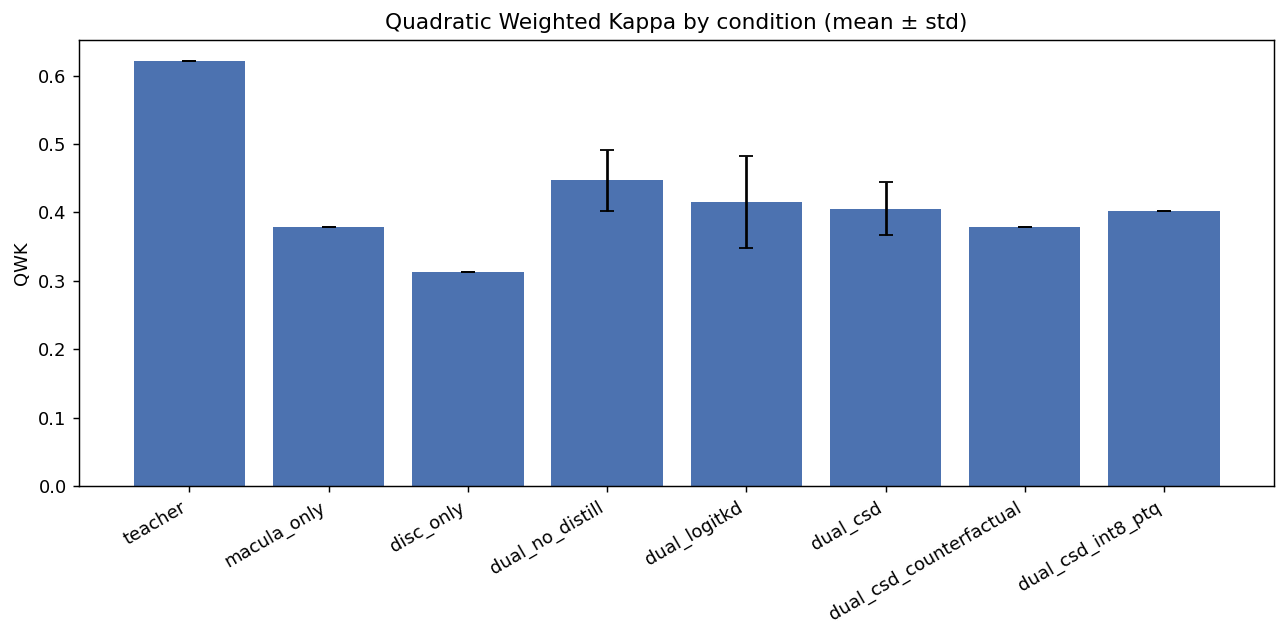

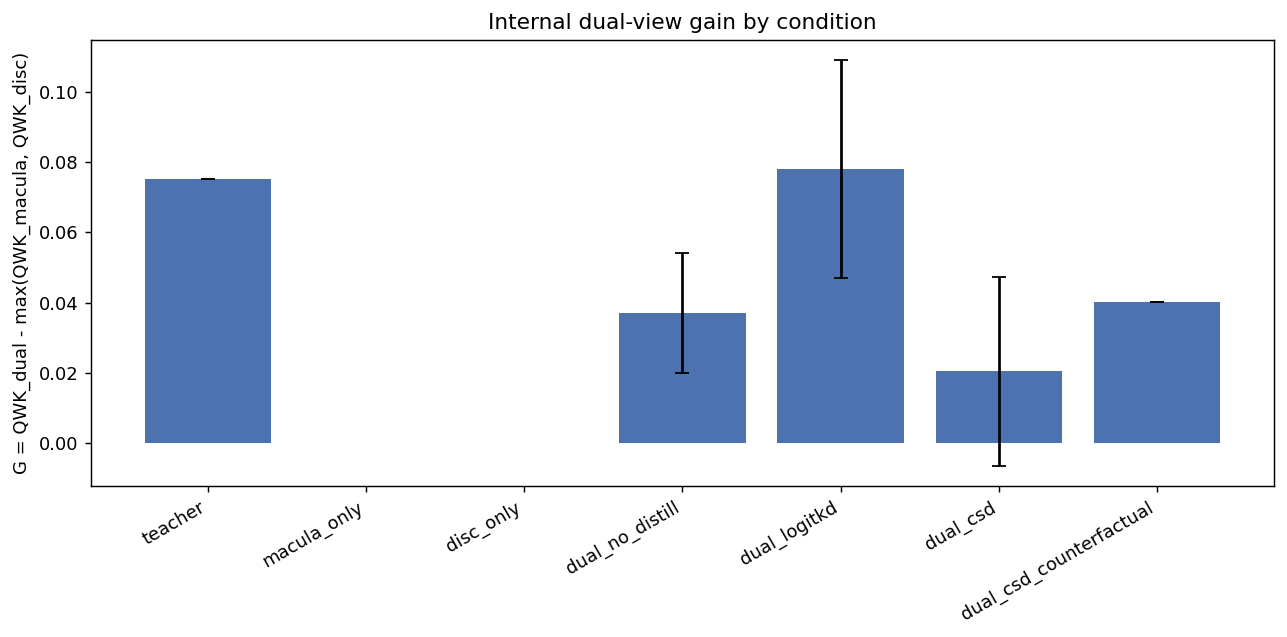

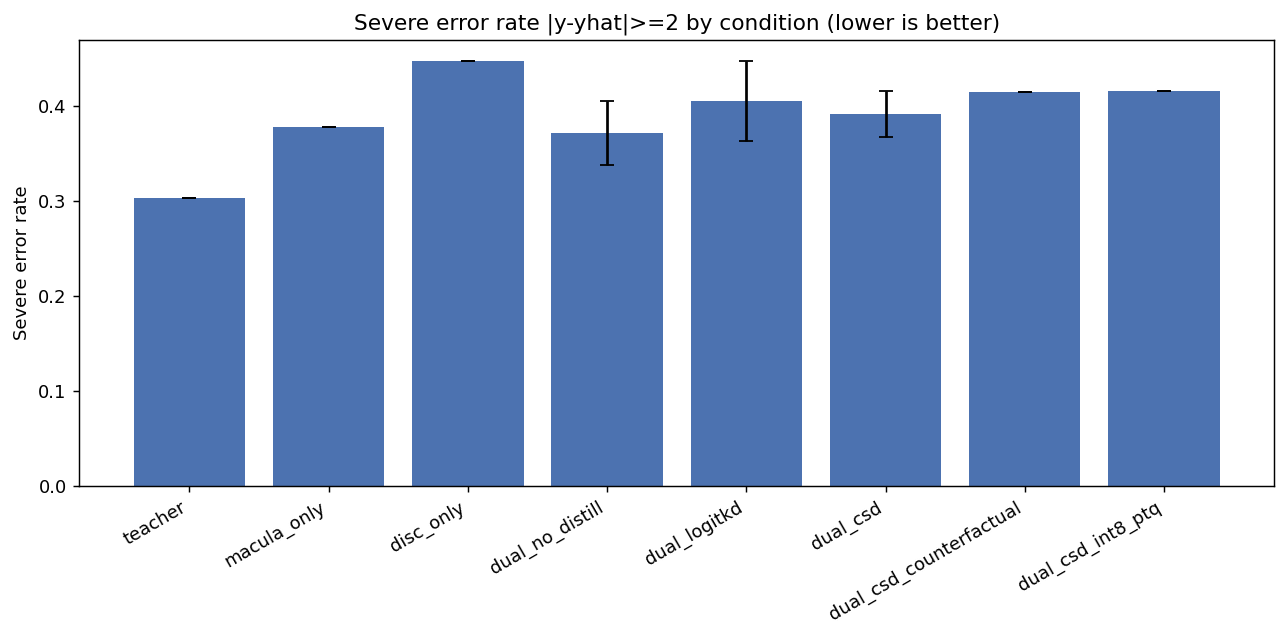

In [35]:
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 130
CORE_ORDER = ["teacher", "macula_only", "disc_only", "dual_no_distill", "dual_logitkd", "dual_csd",
              "dual_csd_counterfactual", "dual_csd_int8_ptq"]
present_order = [c for c in CORE_ORDER if c in raw_df["condition"].unique()]

def condition_mean_std(col):
    means, stds = [], []
    for c in present_order:
        vals = raw_df.loc[raw_df["condition"] == c, col].dropna()
        means.append(vals.mean())
        stds.append(vals.std() if len(vals) > 1 else 0.0)
    return means, stds

def bar_with_error(col, title, ylabel, fname):
    means, stds = condition_mean_std(col)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(present_order, means, yerr=stds, capsize=4, color="#4C72B0")
    ax.set_title(title); ax.set_ylabel(ylabel)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{fname}", bbox_inches="tight")
    plt.show()

bar_with_error("QWK", "Quadratic Weighted Kappa by condition (mean ± std)", "QWK", "bar_qwk_comparison.png")
bar_with_error("DualViewGain_G_internal", "Internal dual-view gain by condition", "G = QWK_dual - max(QWK_macula, QWK_disc)", "bar_dual_view_gain.png")
bar_with_error("SevereErrorRate", "Severe error rate |y-yhat|>=2 by condition (lower is better)", "Severe error rate", "bar_severe_error.png")

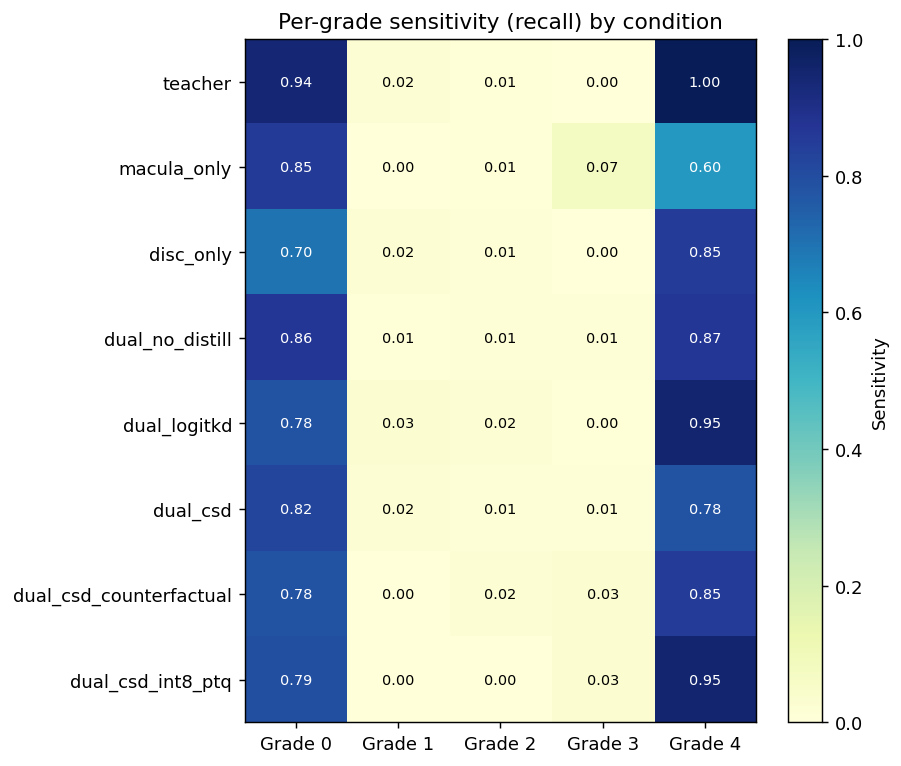

In [36]:
# Per-grade sensitivity heatmap
sens_cols = [f"Sensitivity_Grade{g}" for g in range(5)]
sens_matrix = np.array([[raw_df.loc[raw_df["condition"] == c, col].mean() for col in sens_cols] for c in present_order])
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sens_matrix, cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(5)); ax.set_xticklabels([f"Grade {g}" for g in range(5)])
ax.set_yticks(range(len(present_order))); ax.set_yticklabels(present_order)
for i in range(sens_matrix.shape[0]):
    for j in range(sens_matrix.shape[1]):
        if not np.isnan(sens_matrix[i, j]):
            ax.text(j, i, f"{sens_matrix[i,j]:.2f}", ha="center", va="center",
                    color="white" if sens_matrix[i, j] > 0.5 else "black", fontsize=8)
ax.set_title("Per-grade sensitivity (recall) by condition")
plt.colorbar(im, ax=ax, label="Sensitivity")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/sensitivity_heatmap.png", bbox_inches="tight")
plt.show()

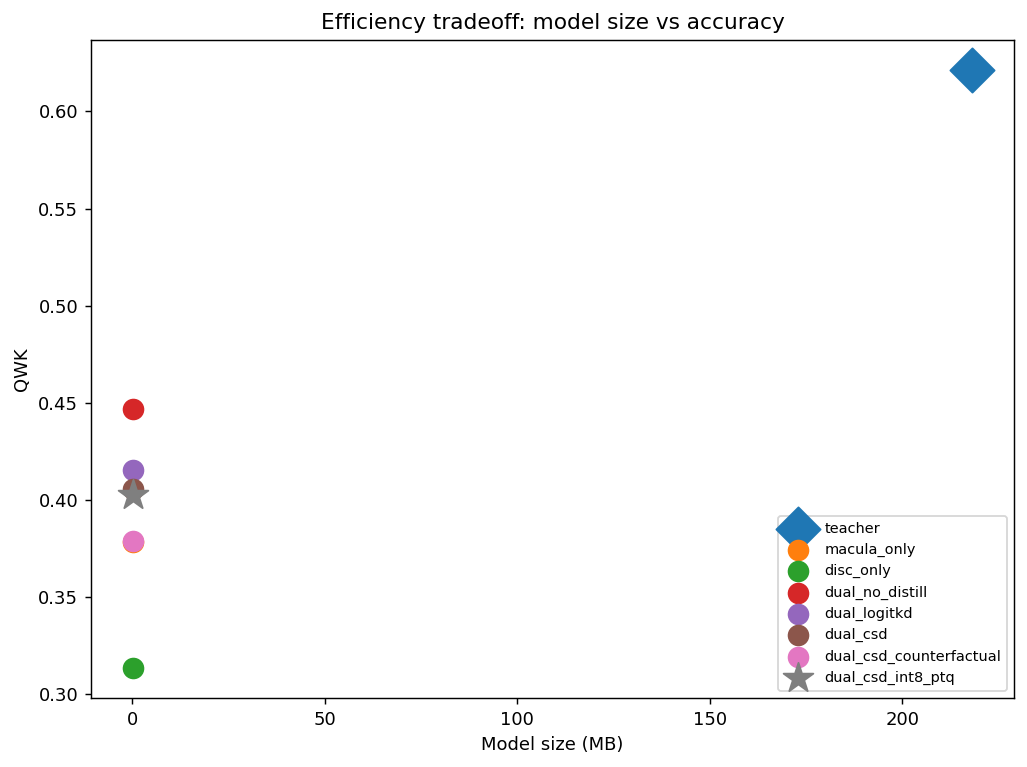

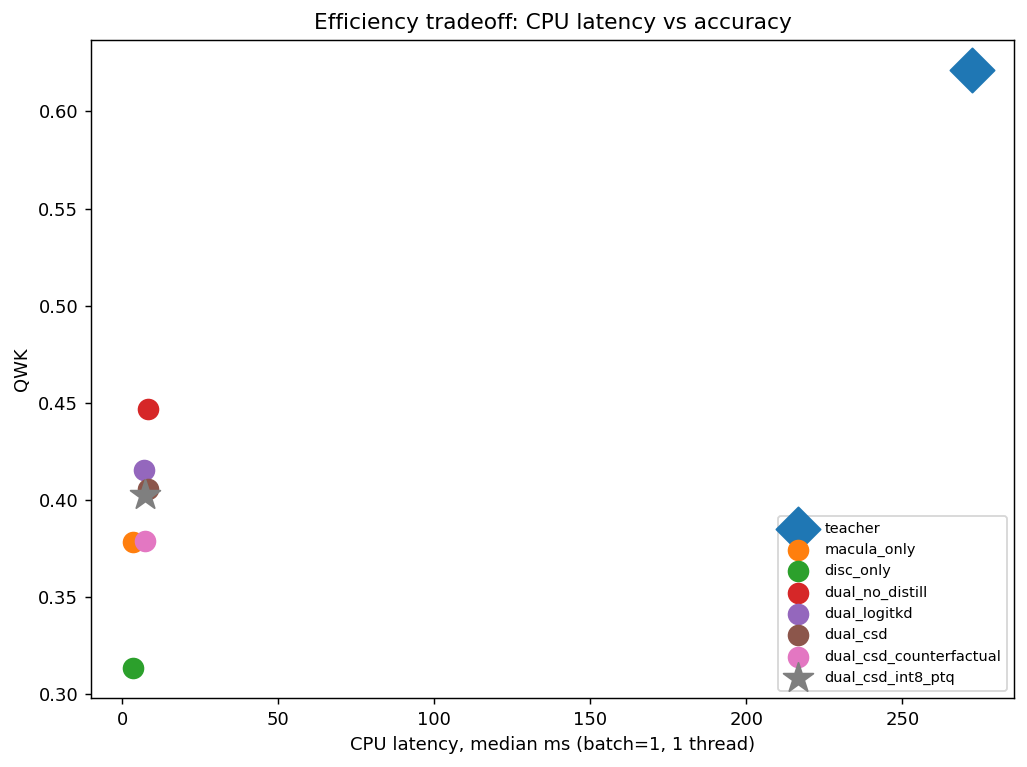

In [37]:
# Efficiency tradeoff: model size vs QWK
fig, ax = plt.subplots(figsize=(8, 6))
for c in present_order:
    sub = raw_df[raw_df["condition"] == c]
    x, y = sub["ModelSize_MB"].mean(), sub["QWK"].mean()
    marker = "*" if "int8" in c else ("D" if c == "teacher" else "o")
    size = 300 if "int8" in c or c == "teacher" else 120
    ax.scatter(x, y, s=size, marker=marker, label=c)
ax.set_xlabel("Model size (MB)"); ax.set_ylabel("QWK")
ax.set_title("Efficiency tradeoff: model size vs accuracy")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/efficiency_scatter.png", bbox_inches="tight")
plt.show()

# Latency vs QWK
fig, ax = plt.subplots(figsize=(8, 6))
for c in present_order:
    sub = raw_df[raw_df["condition"] == c]
    x, y = sub["CPU_Latency_median_ms"].mean(), sub["QWK"].mean()
    marker = "*" if "int8" in c else ("D" if c == "teacher" else "o")
    size = 300 if "int8" in c or c == "teacher" else 120
    ax.scatter(x, y, s=size, marker=marker, label=c)
ax.set_xlabel("CPU latency, median ms (batch=1, 1 thread)"); ax.set_ylabel("QWK")
ax.set_title("Efficiency tradeoff: CPU latency vs accuracy")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/latency_scatter.png", bbox_inches="tight")
plt.show()

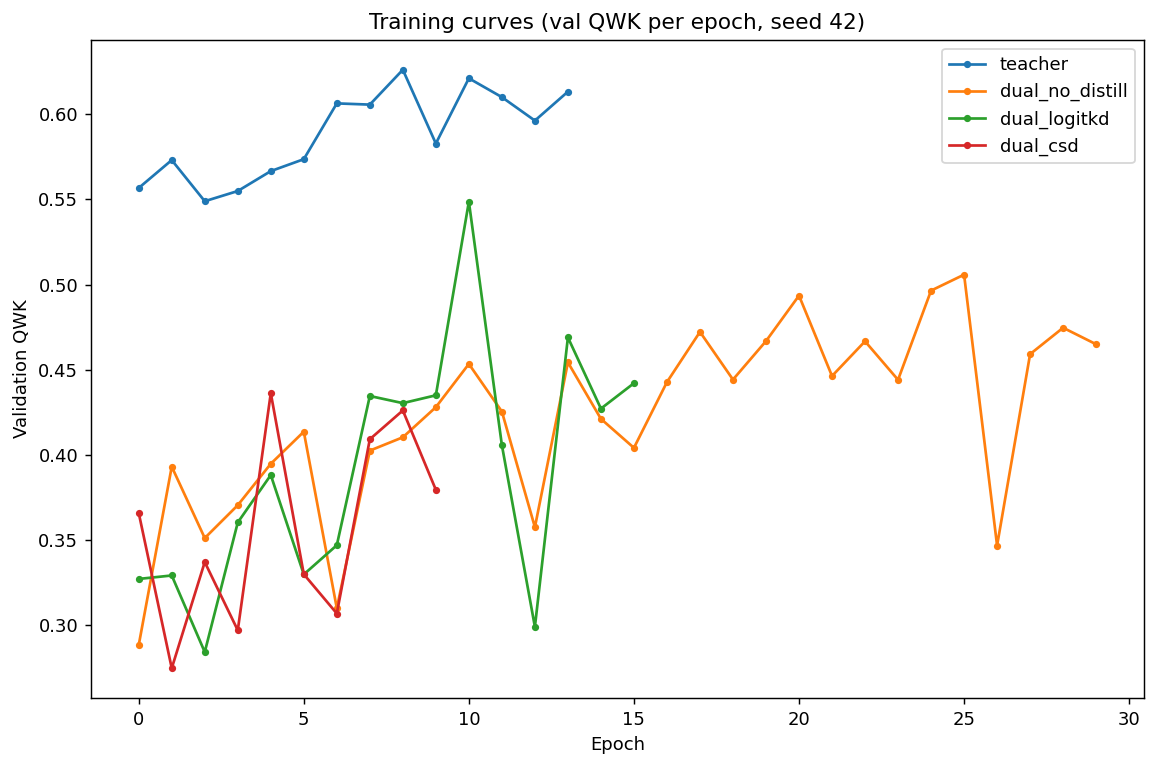

In [38]:
# Training curves: val QWK per epoch for teacher + core 3 conditions
fig, ax = plt.subplots(figsize=(9, 6))
curve_specs = [("teacher_history.csv", "teacher")]
for cond in ["dual_no_distill", "dual_logitkd", "dual_csd"]:
    curve_specs.append((f"{cond}_seed{SEEDS[0]}_history.csv", cond))

for fname, label in curve_specs:
    path = f"{LOGS_DIR}/{fname}"
    if os.path.exists(path):
        hist = pd.read_csv(path)
        ax.plot(hist["epoch"], hist["val_qwk"], marker="o", markersize=3, label=label)

ax.set_xlabel("Epoch"); ax.set_ylabel("Validation QWK")
ax.set_title("Training curves (val QWK per epoch, seed 42)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/training_curves.png", bbox_inches="tight")
plt.show()

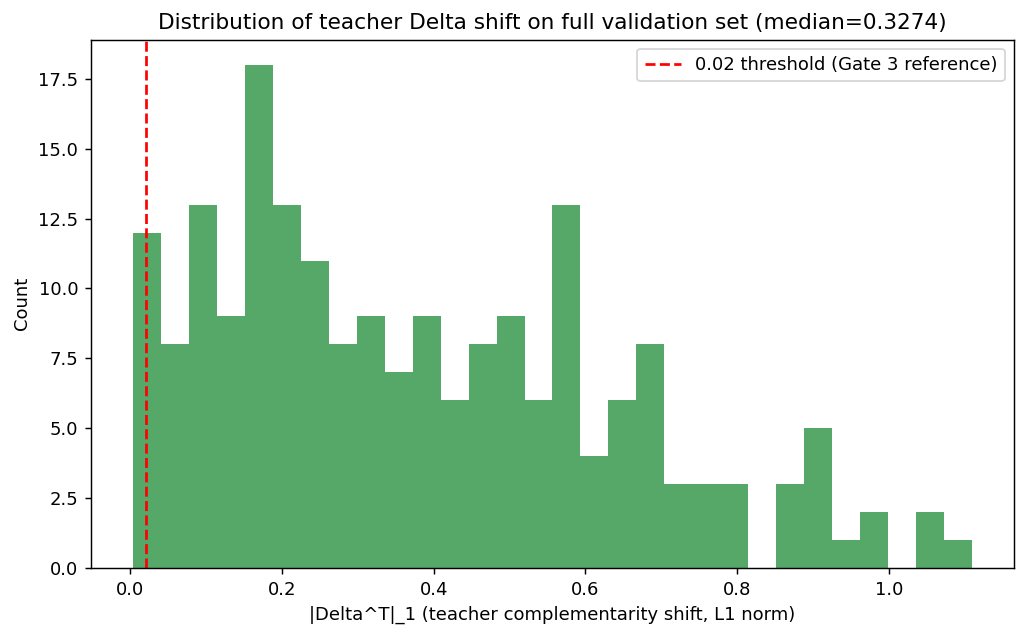

In [39]:
# Delta^T distribution (Gate 3 diagnostic, full val set this time not just one batch)
teacher = get_teacher()
val_loader_full = DataLoader(DRTiDDualViewDataset(DRTID_VAL_CSV, eval_transform), batch_size=16, shuffle=False, num_workers=2)
all_l1 = []
with torch.no_grad():
    for batch in val_loader_full:
        macula, disc = batch["macula"].to(DEVICE), batch["disc"].to(DEVICE)
        out = teacher(macula, disc)
        delta_t = _compute_delta(out["p_dual"], out["p_macula"], out["p_disc"])
        all_l1.extend(delta_t.abs().sum(dim=1).cpu().tolist())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(all_l1, bins=30, color="#55A868")
ax.axvline(0.02, color="red", linestyle="--", label="0.02 threshold (Gate 3 reference)")
ax.set_xlabel("|Delta^T|_1 (teacher complementarity shift, L1 norm)")
ax.set_ylabel("Count")
ax.set_title(f"Distribution of teacher Delta shift on full validation set (median={np.median(all_l1):.4f})")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/delta_distribution.png", bbox_inches="tight")
plt.show()

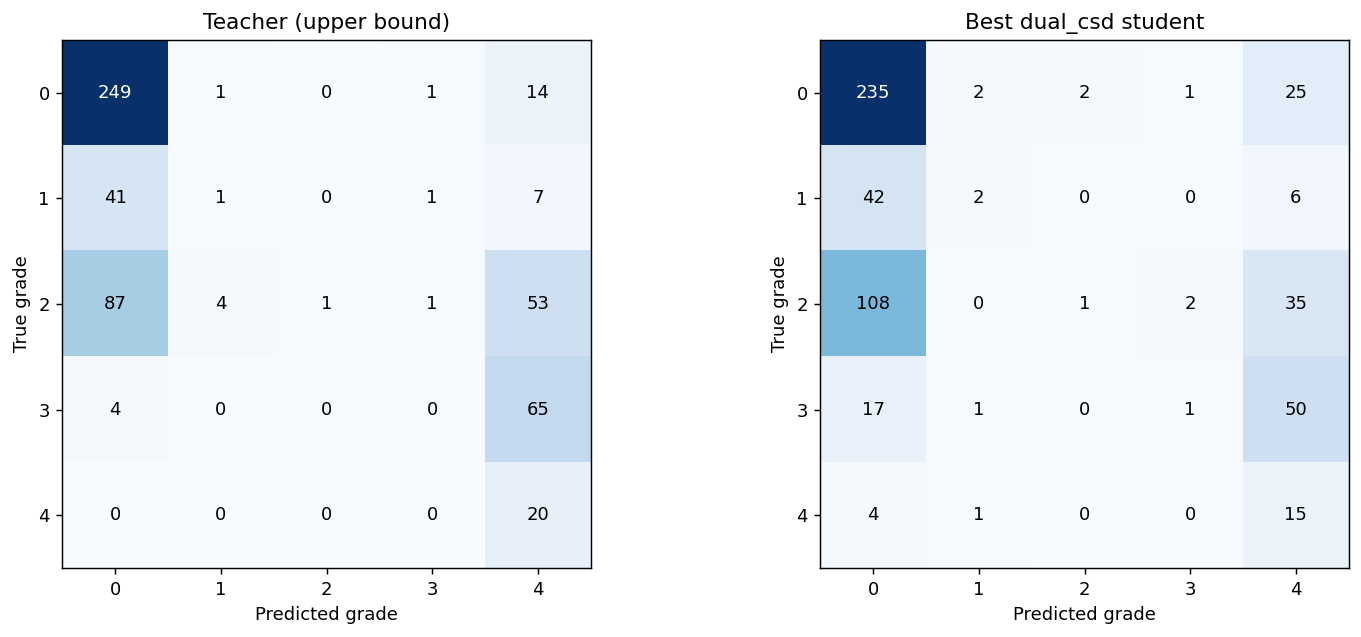

In [40]:
# Confusion matrices: teacher vs best dual_csd seed
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (label, model_ref) in zip(axes, [("Teacher (upper bound)", teacher), ("Best dual_csd student", None)]):
    if model_ref is None:
        model_ref = DualViewLightStudent(NUM_CLASSES).to(DEVICE)
        model_ref.load_state_dict(torch.load(f"{CKPT_DIR}/student/dual_csd/best_seed{BEST_CSD_SEED}.pt", map_location=DEVICE)["model_state"])
    y_true, y_pred, _ = get_predictions(model_ref, TEST_LOADER, DEVICE, "dual")
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3, 4])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(label)
    ax.set_xlabel("Predicted grade"); ax.set_ylabel("True grade")
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
    for i in range(5):
        for j in range(5):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/confusion_matrices.png", bbox_inches="tight")
plt.show()

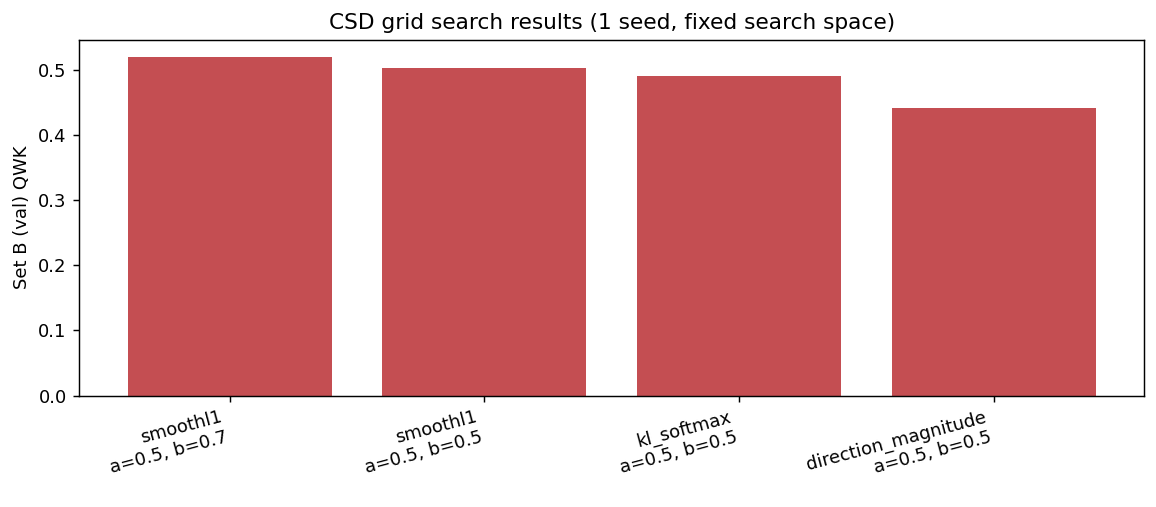


All figures saved to /content/drive/MyDrive/DR-VERGE/results/figures


In [41]:
# Ablation grid heatmap (CSD variant x alpha x beta, Set B QWK)
fig, ax = plt.subplots(figsize=(9, 4))
labels = [f"{r.csd_variant}\na={r.alpha}, b={r.beta}" for r in grid_df.itertuples()]
ax.bar(labels, grid_df["val_QWK"], color="#C44E52")
ax.set_ylabel("Set B (val) QWK")
ax.set_title("CSD grid search results (1 seed, fixed search space)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/ablation_grid.png", bbox_inches="tight")
plt.show()
print(f"\nAll figures saved to {FIGURES_DIR}")

## 20. Final results dashboard

In [42]:
print("=" * 78)
print("DR-VERGE -- FINAL RESULTS DASHBOARD")
print("=" * 78)
print("\nPer-condition (mean +/- std where applicable):\n")
display_cols = ["QWK", "MAE", "SevereErrorRate", "MacroF1", "DualViewGain_G_internal"]
summary_rows = []
for c in present_order:
    sub = raw_df[raw_df["condition"] == c]
    row = {"condition": c, "n_seeds": len(sub)}
    for col in display_cols:
        vals = sub[col].dropna()
        row[col] = f"{vals.mean():.4f} +/- {vals.std():.4f}" if len(vals) > 1 else (f"{vals.mean():.4f}" if len(vals) else "-")
    summary_rows.append(row)
summary_table = pd.DataFrame(summary_rows)
print(summary_table.to_string(index=False))

summary_table.to_csv(f"{METRICS_DIR}/final_summary_table.csv", index=False)
with open(f"{METRICS_DIR}/final_summary_table.md", "w") as f:
    f.write(summary_table.to_markdown(index=False))

print(f"\nAll checkpoints:  {CKPT_DIR}")
print(f"All metrics CSVs: {METRICS_DIR}")
print(f"All figures:      {FIGURES_DIR}")
print(f"Training logs:    {LOGS_DIR}")
print("\nRemember: Gate 4's verdict on RQ1 (Section 18 above) is the headline result --")
print("re-read it before writing the paper's Results section, and use judge.md Section I's")
print("safe phrasing for every claim (\'operational proxy\', not \'proves complementarity\').")

DR-VERGE -- FINAL RESULTS DASHBOARD

Per-condition (mean +/- std where applicable):

              condition  n_seeds               QWK               MAE   SevereErrorRate           MacroF1 DualViewGain_G_internal
                teacher        1            0.6214            0.8836            0.3036            0.2087                  0.0752
            macula_only        1            0.3784            1.1182            0.3782            0.1961                       -
              disc_only        1            0.3135            1.3636            0.4473            0.1705                       -
        dual_no_distill        3 0.4469 +/- 0.0449 1.0945 +/- 0.1265 0.3715 +/- 0.0333 0.1918 +/- 0.0212       0.0371 +/- 0.0170
           dual_logitkd        3 0.4154 +/- 0.0675 1.2170 +/- 0.1680 0.4055 +/- 0.0419 0.1928 +/- 0.0141       0.0781 +/- 0.0310
               dual_csd        3 0.4058 +/- 0.0386 1.1733 +/- 0.1045 0.3915 +/- 0.0241 0.1897 +/- 0.0111       0.0204 +/- 0.0269
dual_csd_cou

## Done

This notebook trained and evaluated every condition in `docs/roadmap.md`'s experiment matrix,
generated all figures, and saved everything to Drive. Next steps live outside this notebook:

- Read Section 18's Gate 4 verdict and Section 17's bootstrap CIs before writing the paper's
  Results section — they are the actual answer to RQ1, not a formality to skip.
- Pull the limitations list from `docs/judge.md` Section H / the "safe sentences" in Section I
  directly into the paper's Limitations section.
- If `PTQ_SUCCEEDED` is False, report RQ2 as future work rather than debugging further —
  RQ1 being fully and credibly answered matters more than a rushed RQ2.